In [45]:
import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns
from imblearn.over_sampling import ADASYN, SMOTE, BorderlineSMOTE, RandomOverSampler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.feature_selection import SelectKBest, f_classif, chi2, mutual_info_classif  # ANOVA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score
)
from sklearn.model_selection import GridSearchCV, cross_val_score, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.utils import class_weight

%matplotlib inline

In [46]:
wine_data = pd.read_csv("WineQT.csv")

In [47]:
wine_data.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


In [48]:
wine_data.tail()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
1138,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6,1592
1139,6.8,0.620,0.08,1.9,0.068,28.0,38.0,0.99651,3.42,0.82,9.5,6,1593
1140,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5,1594
1141,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6,1595
1142,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5,1597


In [49]:
df = wine_data.copy()
del df["Id"] # usunięcie id
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [50]:
df.isnull().sum()
# nie brakuje danych

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

In [51]:
df.describe() 

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000
mean,8.311111,0.531339,0.268364,2.532152,0.086933,15.615486,45.914698,0.996730,3.311015,0.657708,10.442111,5.657043
std,1.747595,0.179633,0.196686,1.355917,0.047267,10.250486,32.782130,0.001925,0.156664,0.170399,1.082196,0.805824
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.392500,0.090000,1.900000,0.070000,7.000000,21.000000,0.995570,3.205000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,37.000000,0.996680,3.310000,0.620000,10.200000,6.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,61.000000,0.997845,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,68.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


In [52]:
df.describe()[1:].style.background_gradient()
# dane posiadają różne skale, będzie to miało wpływ na wynik bez normalizacji

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
mean,8.311111,0.531339,0.268364,2.532152,0.086933,15.615486,45.914698,0.996730,3.311015,0.657708,10.442111,5.657043
std,1.747595,0.179633,0.196686,1.355917,0.047267,10.250486,32.782130,0.001925,0.156664,0.170399,1.082196,0.805824
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.392500,0.090000,1.900000,0.070000,7.000000,21.000000,0.995570,3.205000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,37.000000,0.996680,3.310000,0.620000,10.200000,6.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,61.000000,0.997845,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,68.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


In [53]:
df.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='object')

In [54]:
columns = ['fixed acidity', 'volatile acidity', 'citric acid',
       'residual sugar', 'chlorides', 'free sulfur dioxide',
       'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']

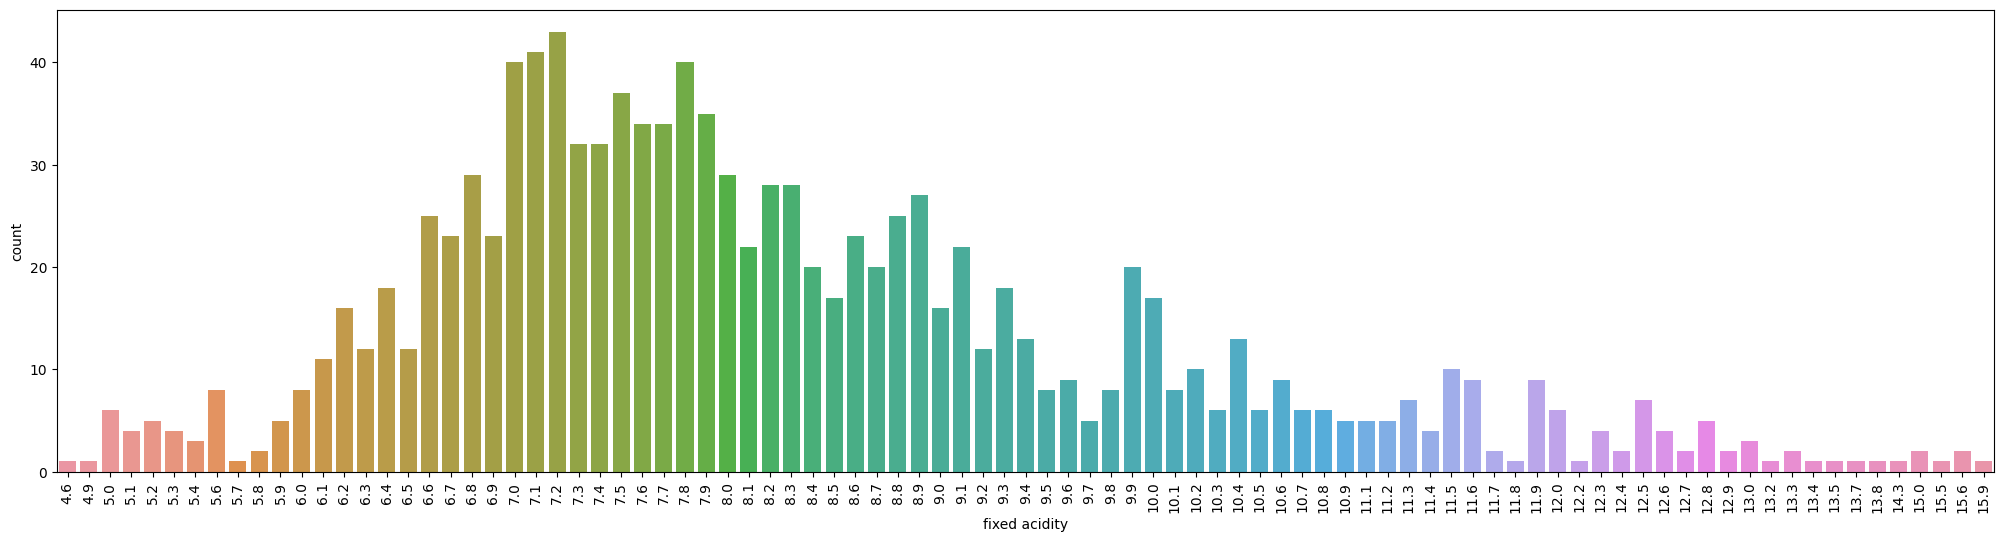

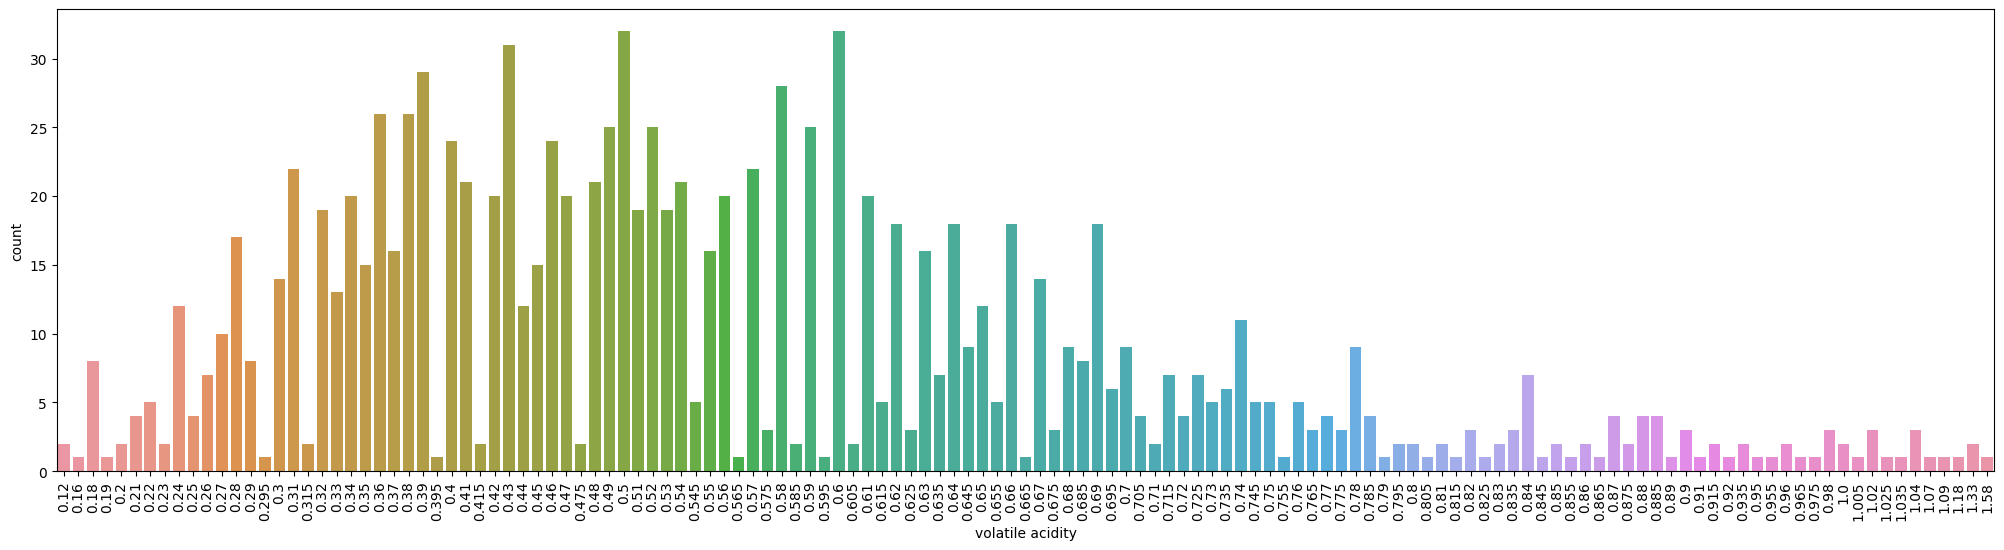

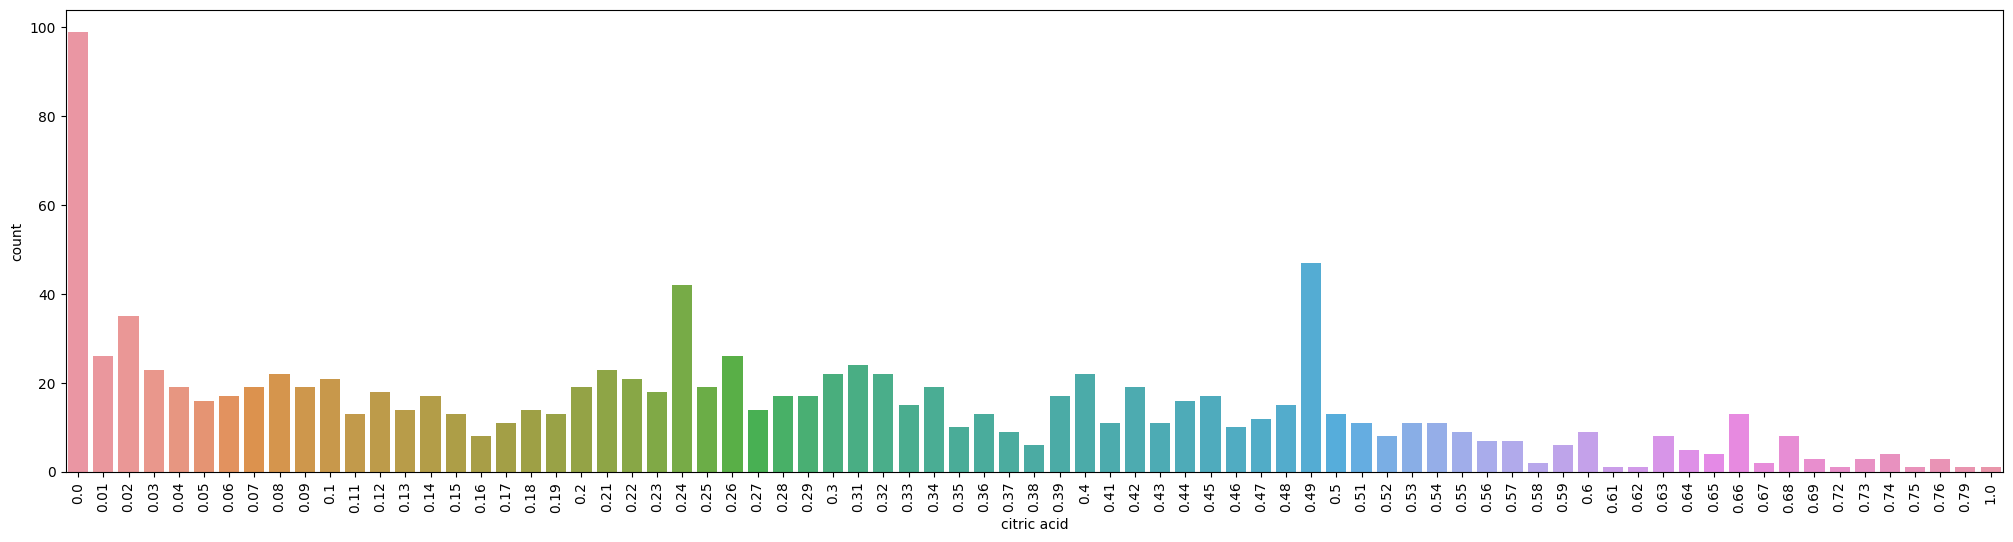

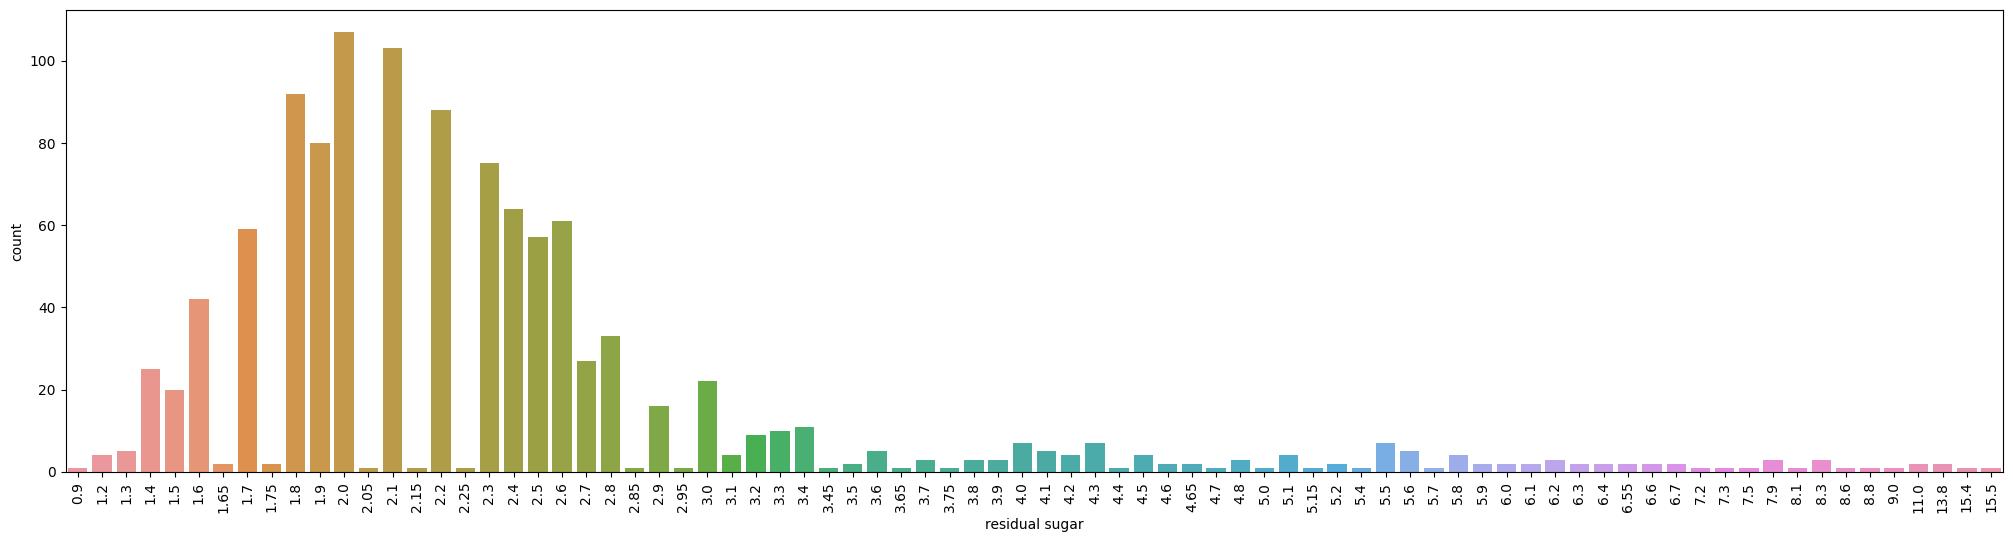

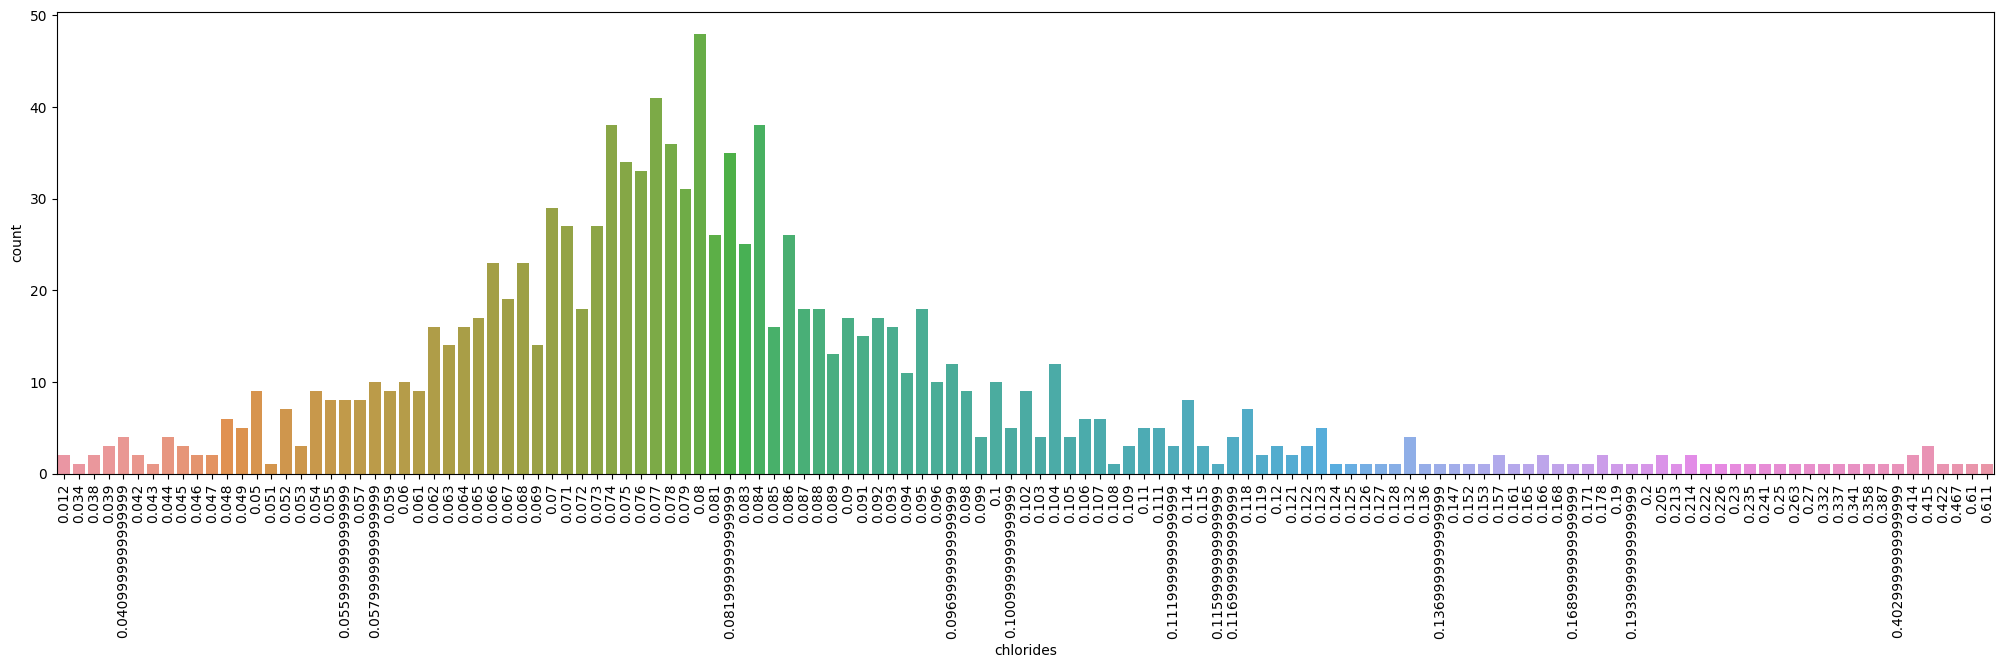

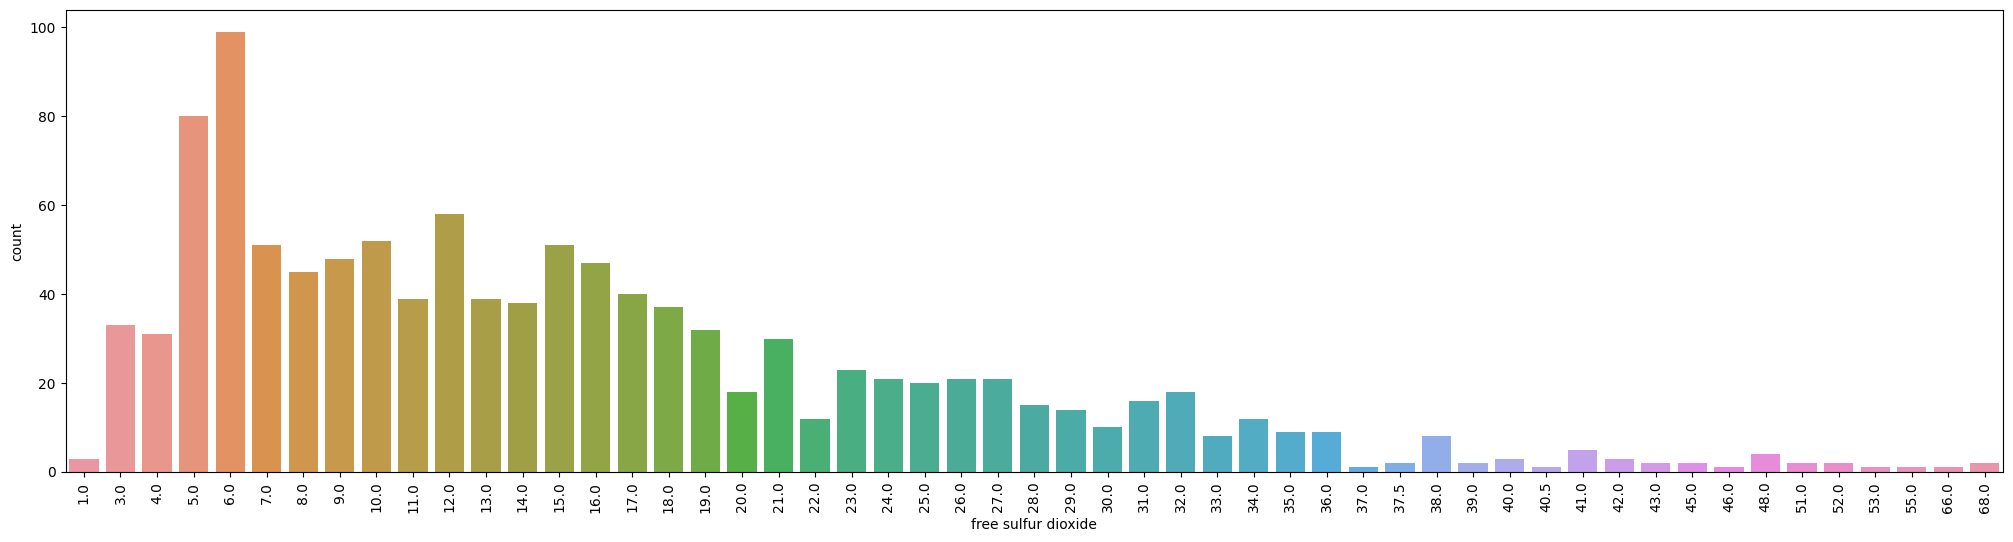

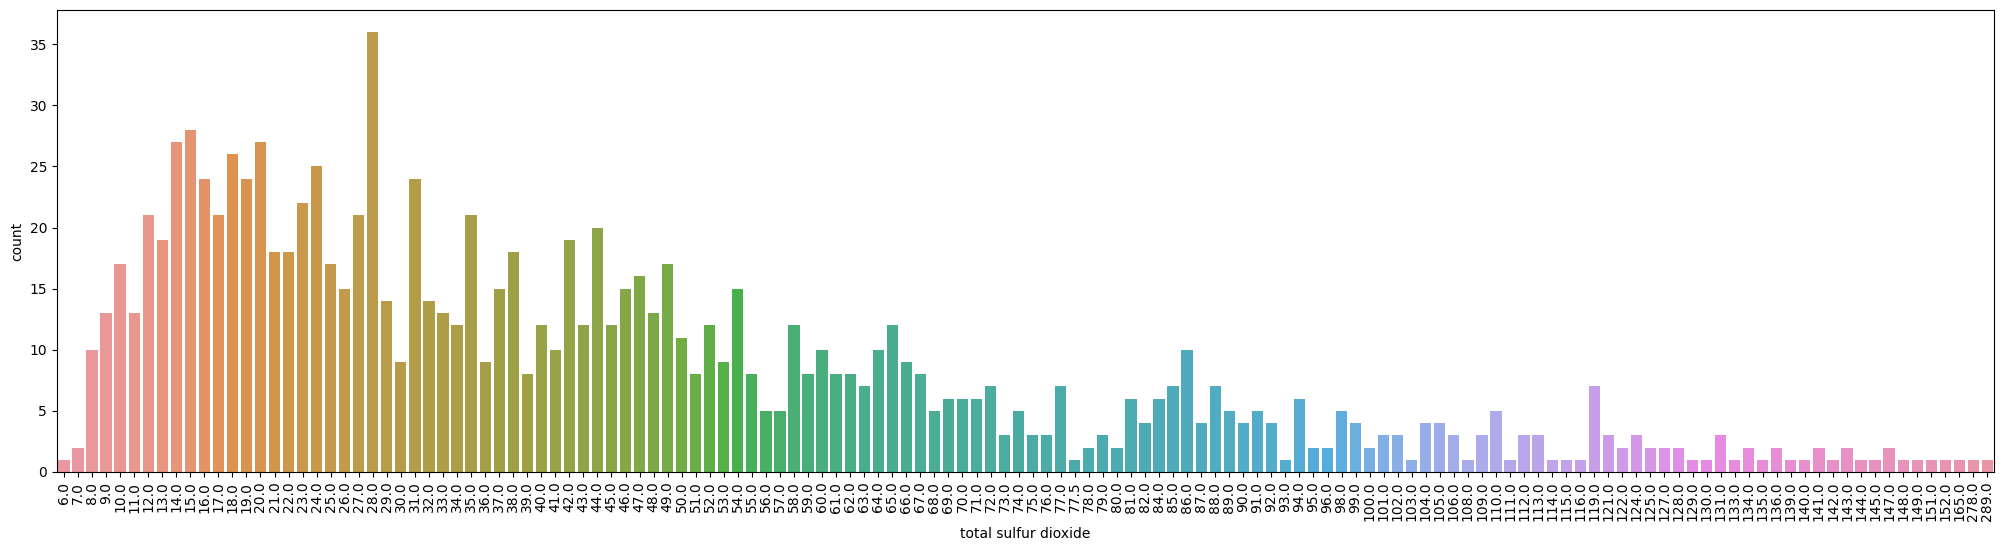

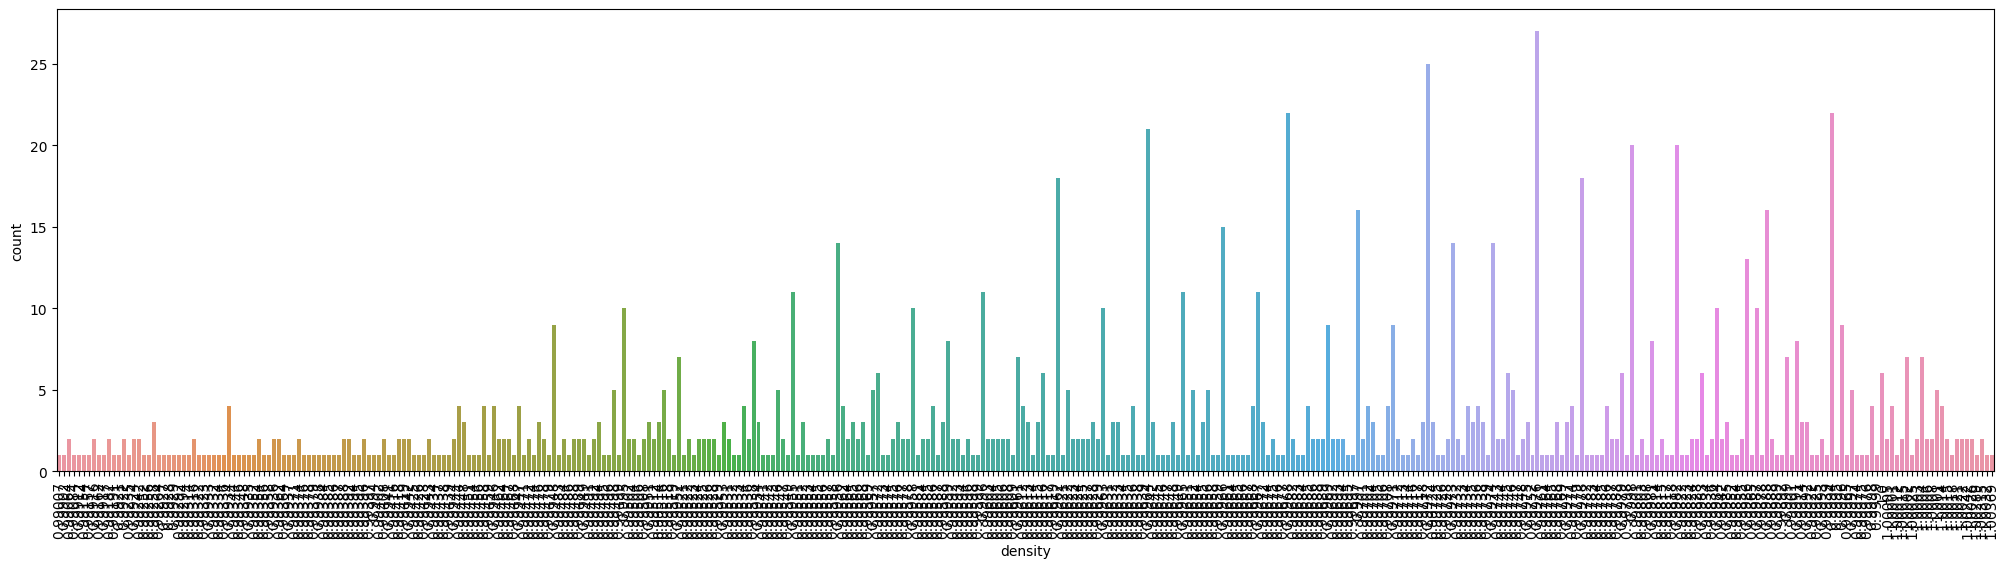

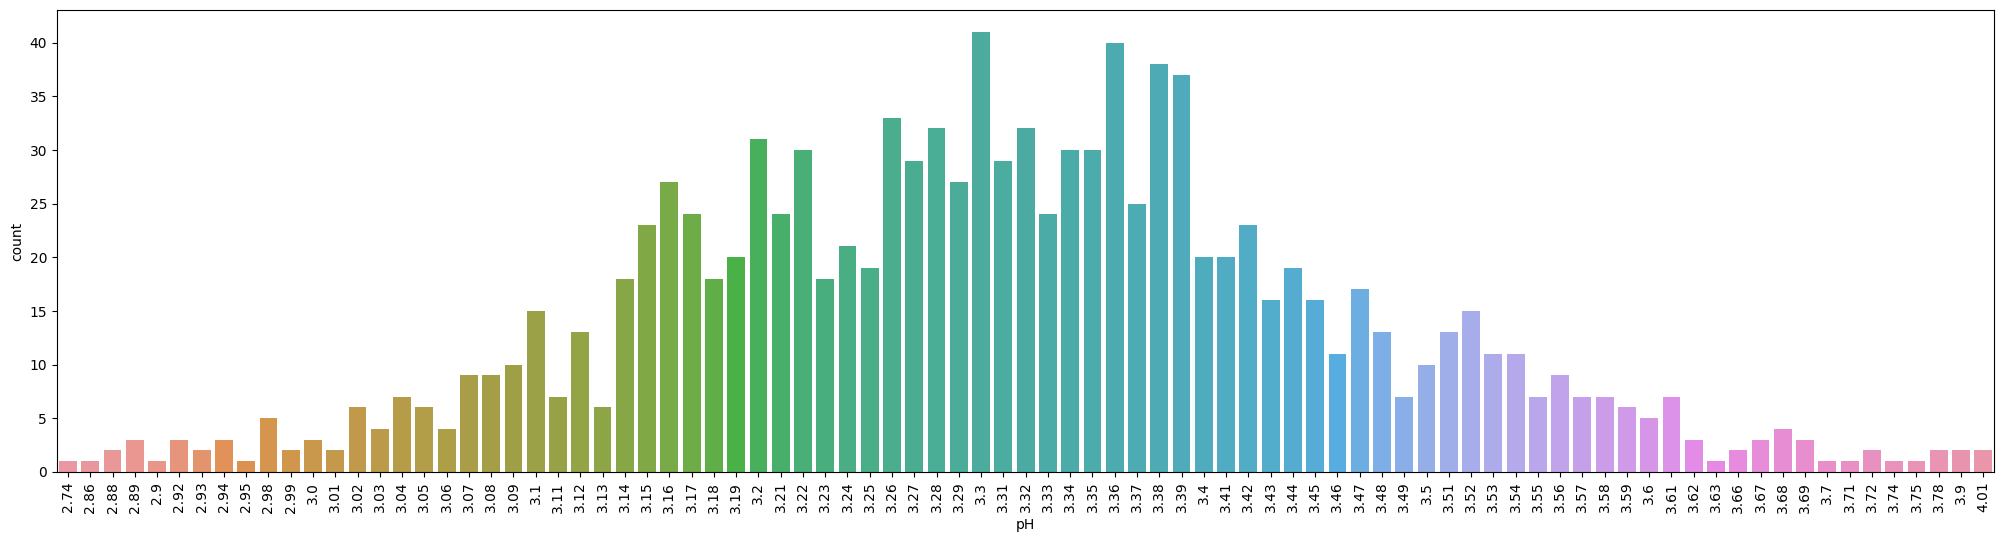

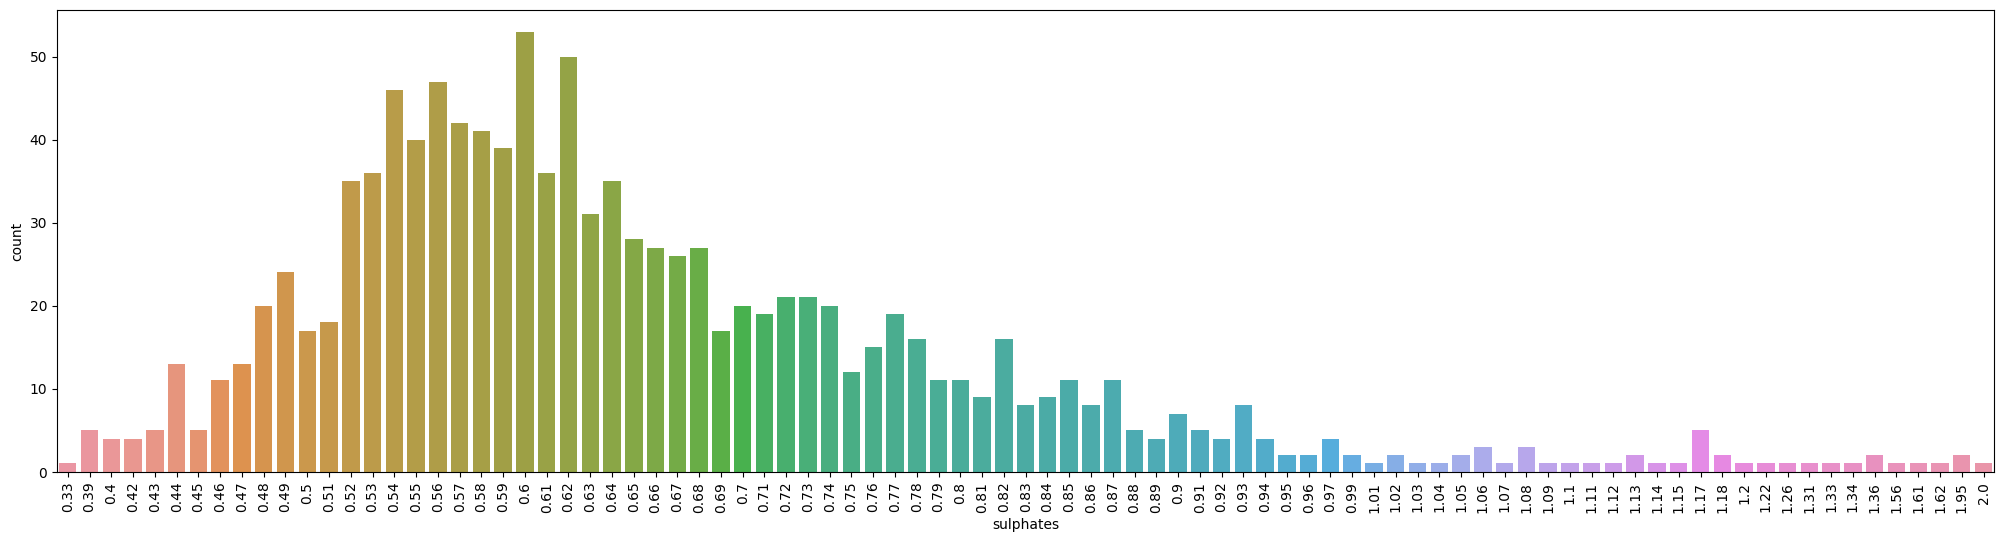

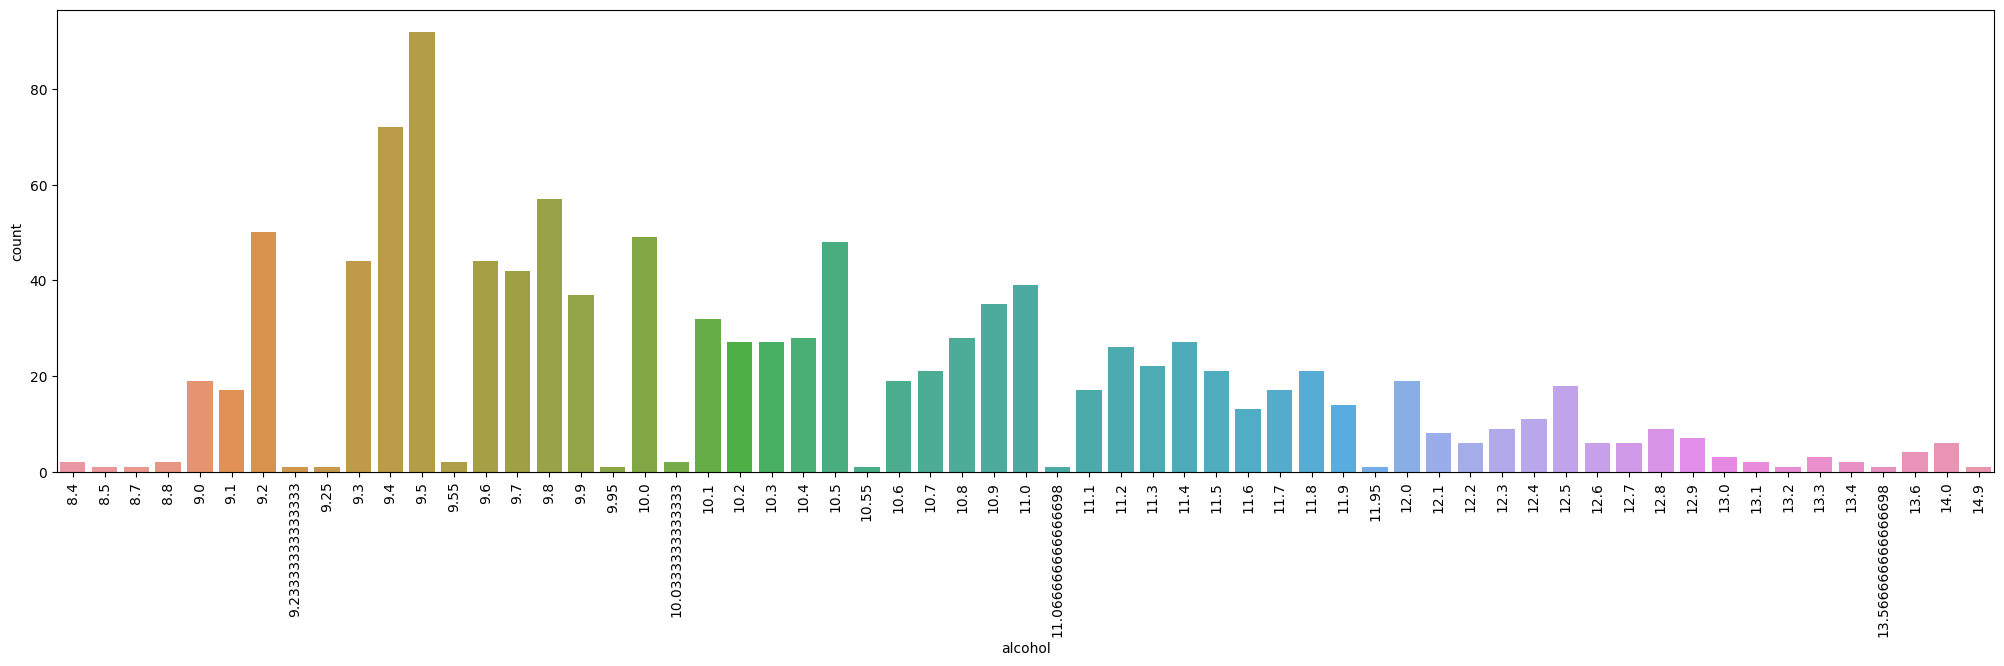

In [55]:
for column in columns:
    plt.figure(figsize = (25,6))
    sns.countplot(x = df[column], data=df)
    plt.xticks(rotation=90)
    plt.show()

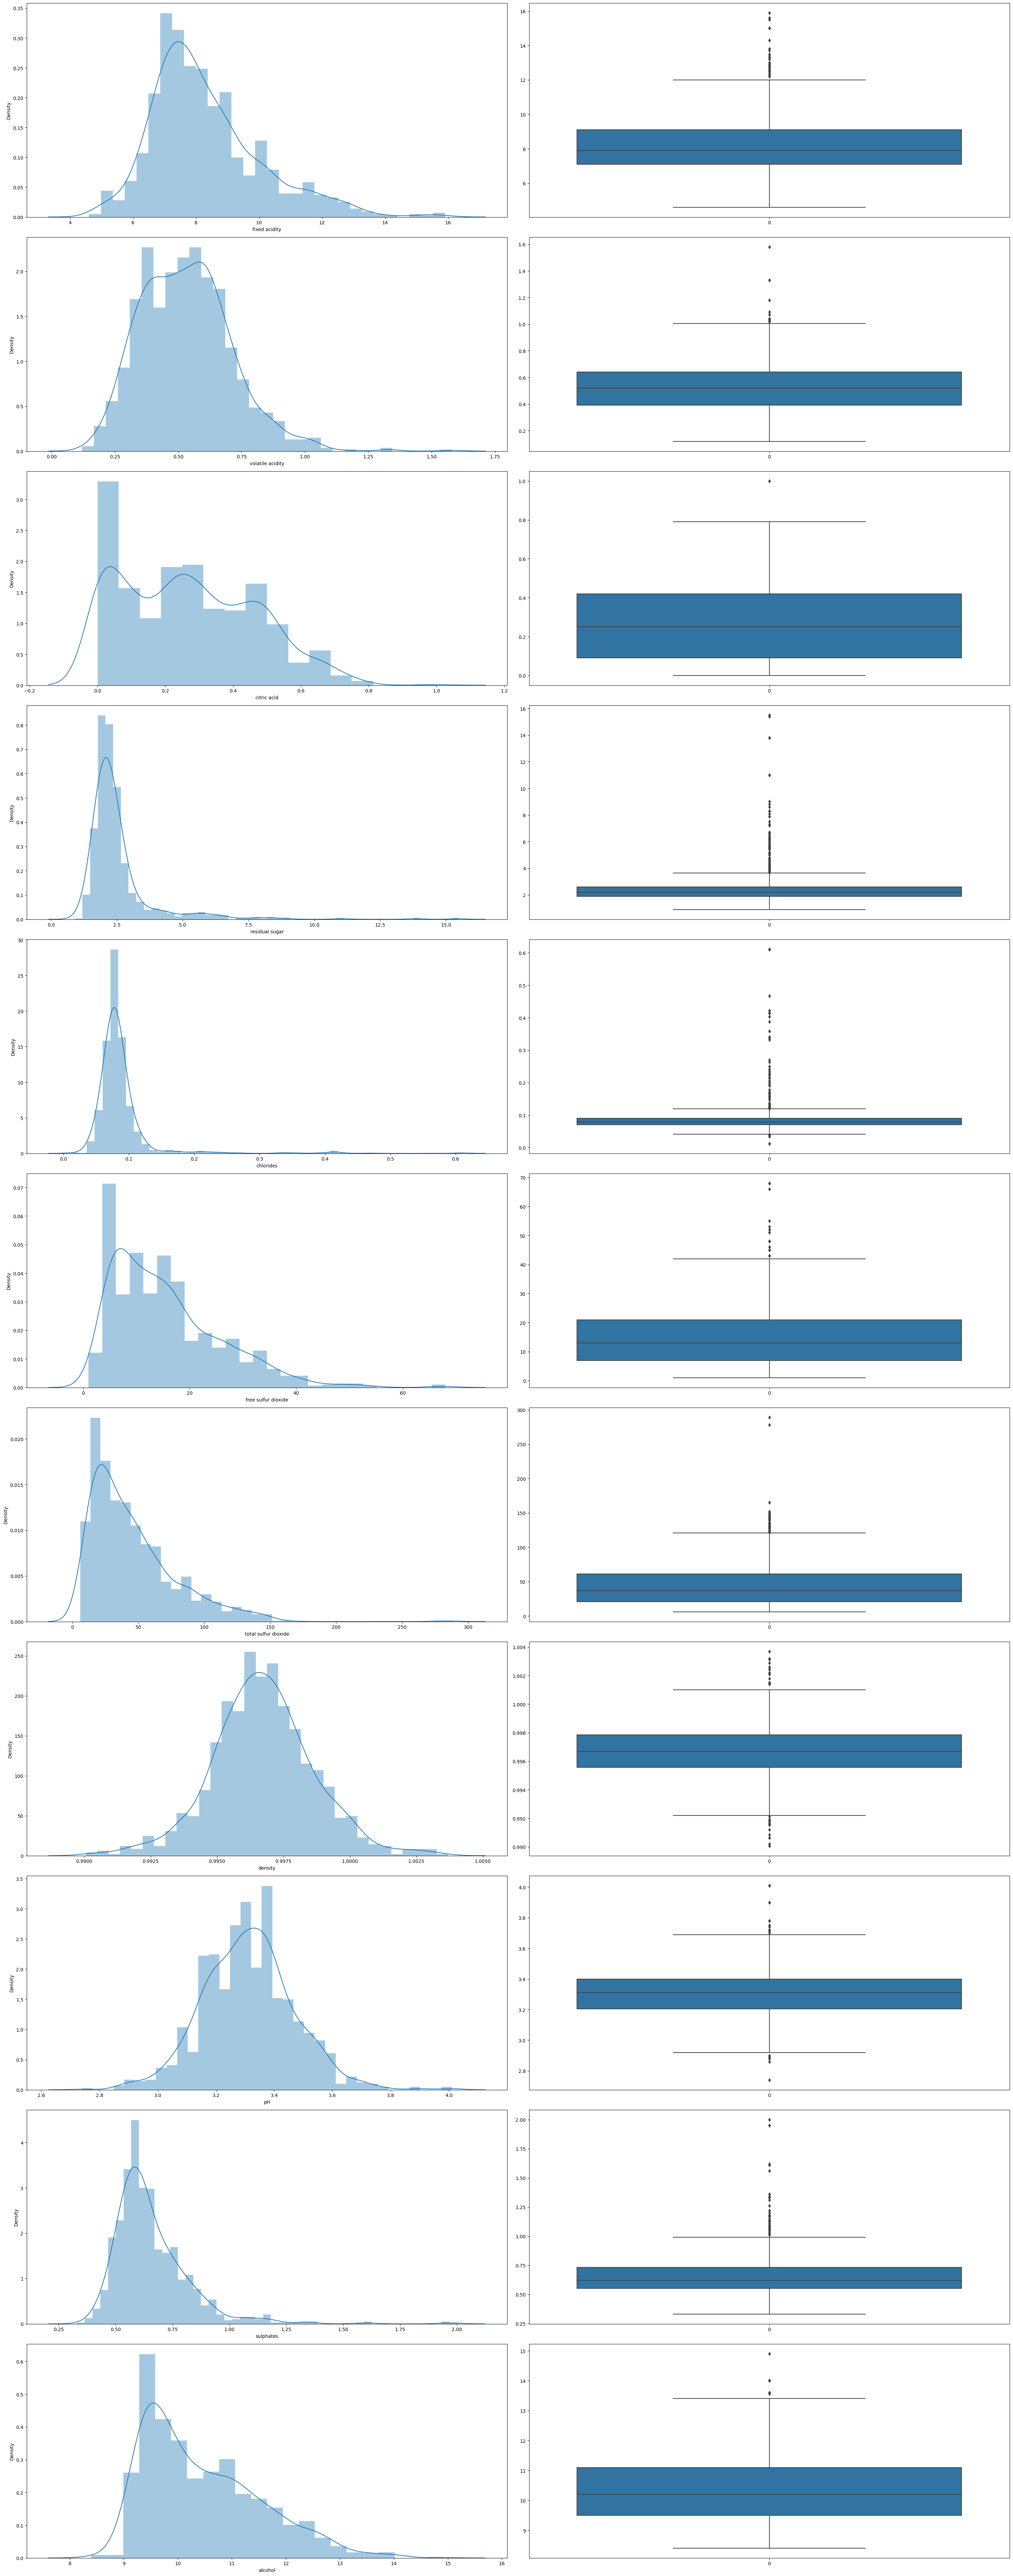

In [111]:
warnings.filterwarnings("ignore")

fig, ax = plt.subplots(11, 2, figsize=(30, 80))

for index, i in enumerate(df.select_dtypes(include=["float64"]).columns):
    sns.distplot(df[i], ax=ax[index, 0])
    sns.boxplot(df[i], ax=ax[index, 1])

fig.tight_layout()
fig.subplots_adjust(top=0.95)

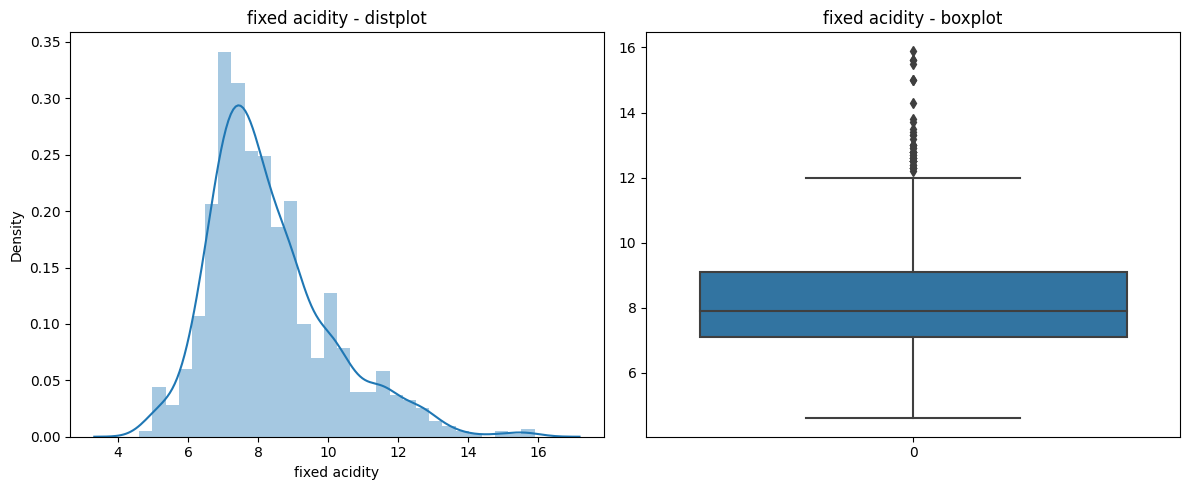

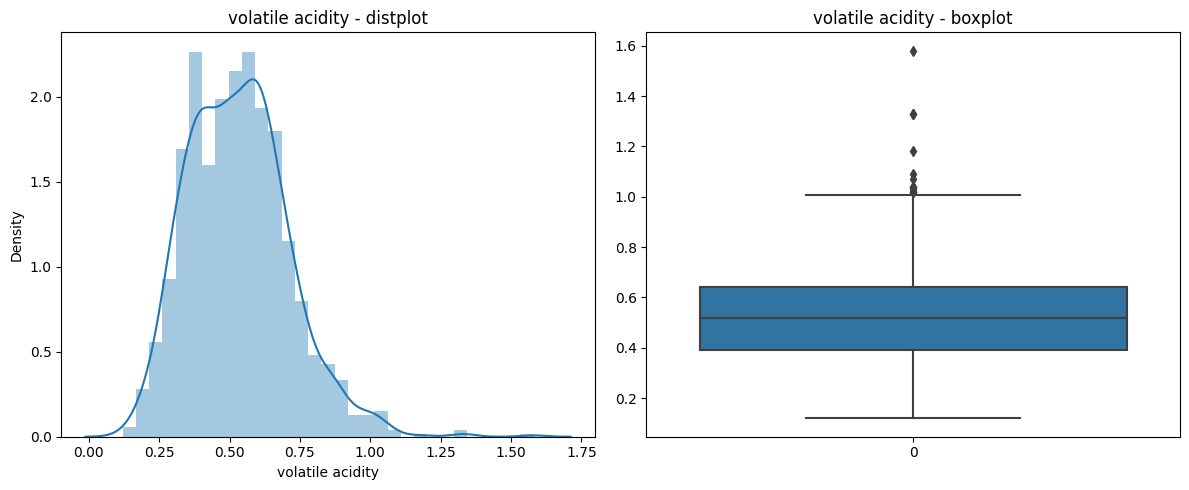

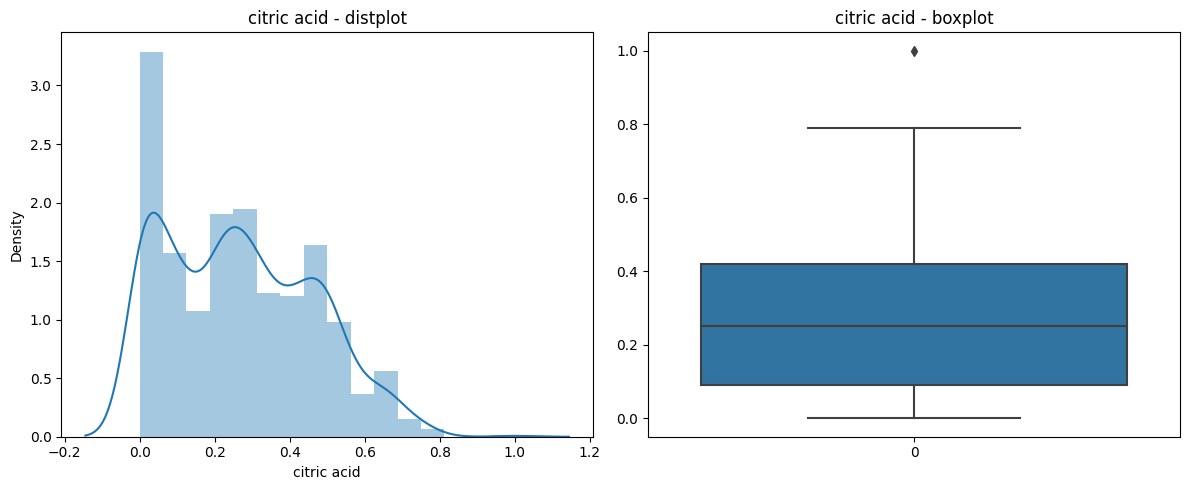

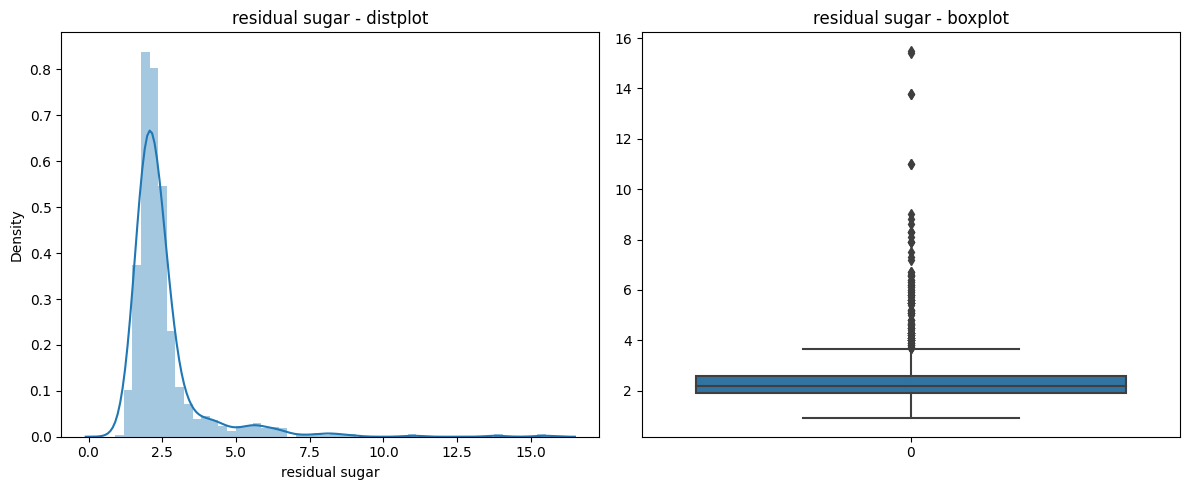

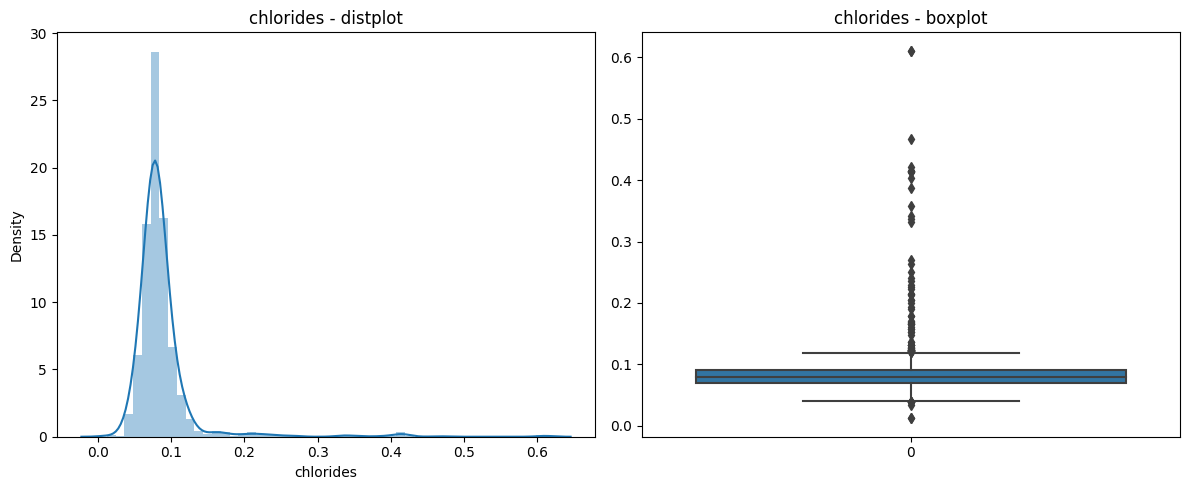

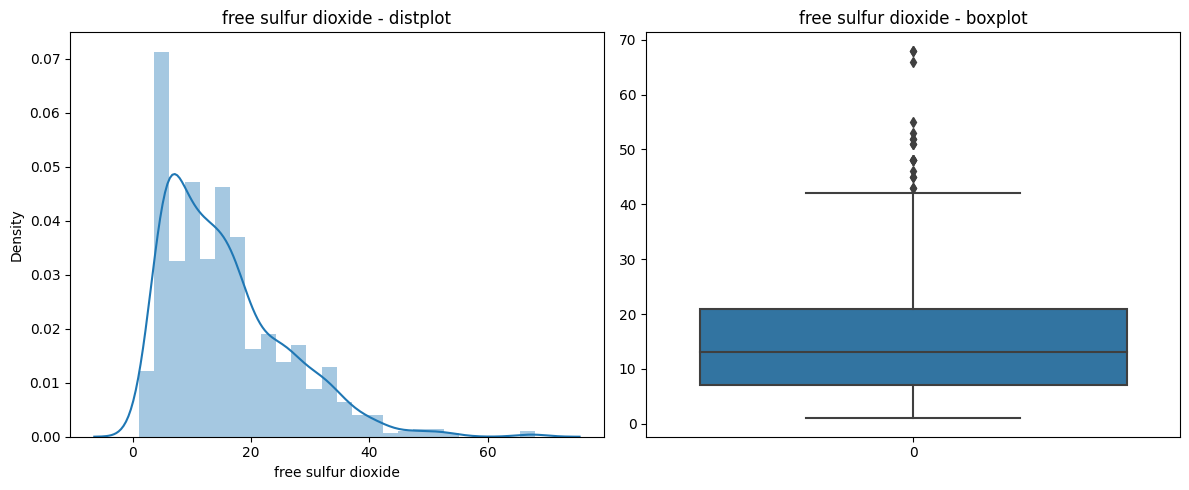

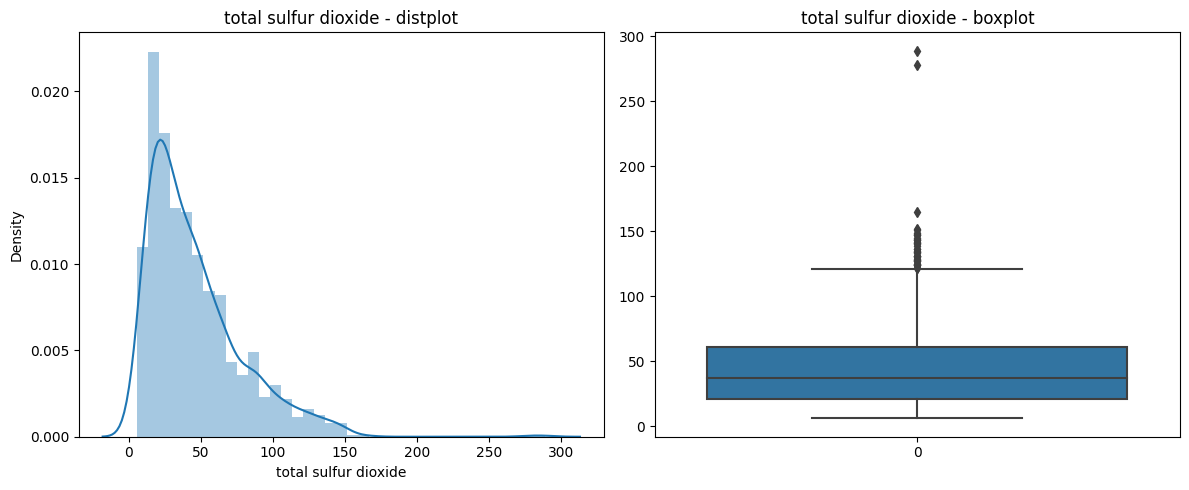

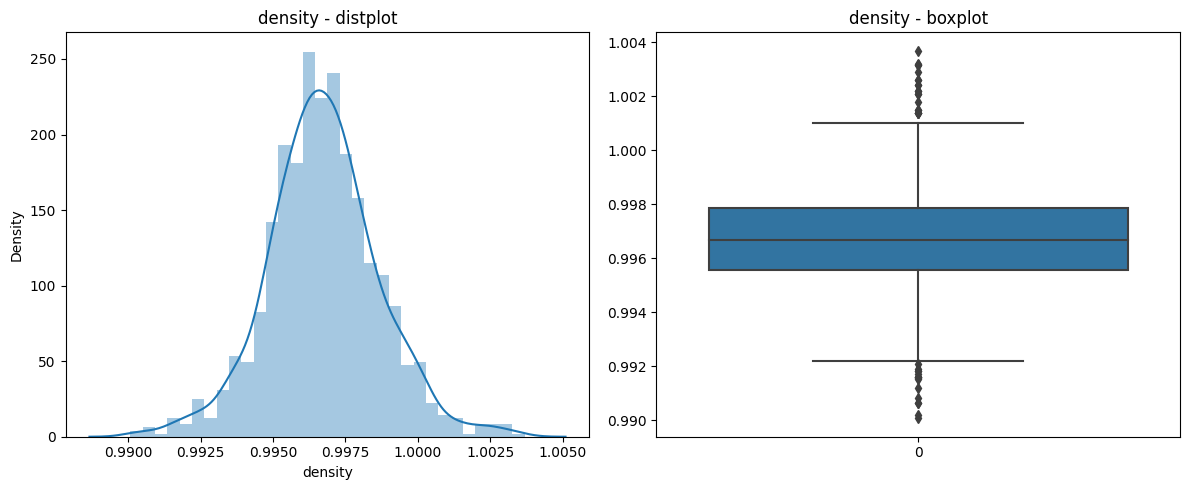

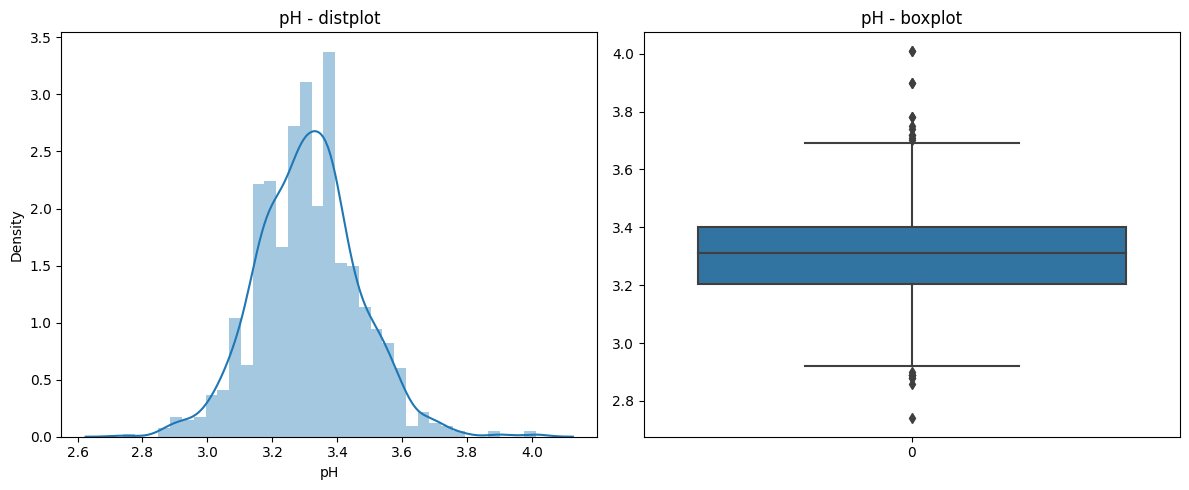

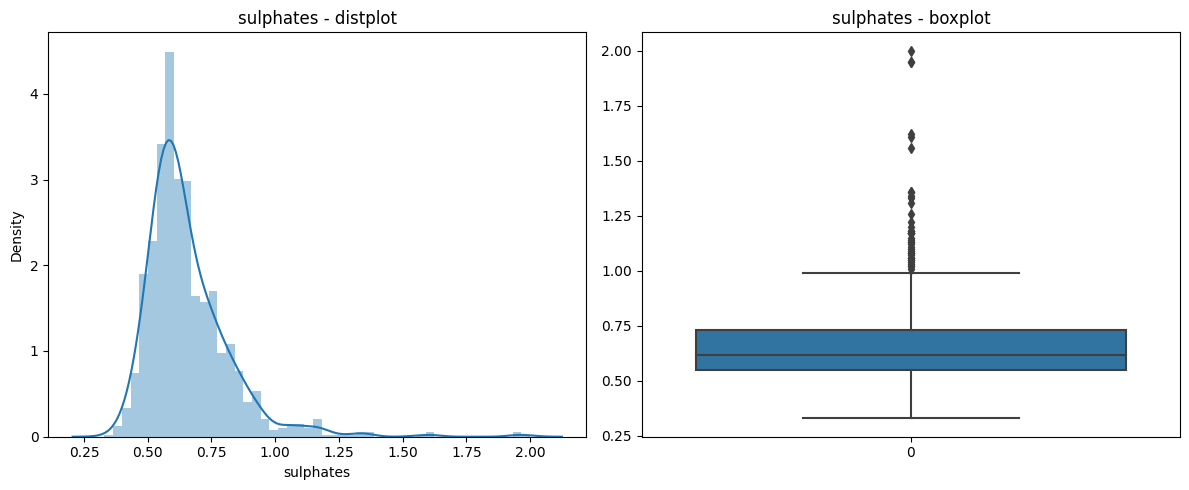

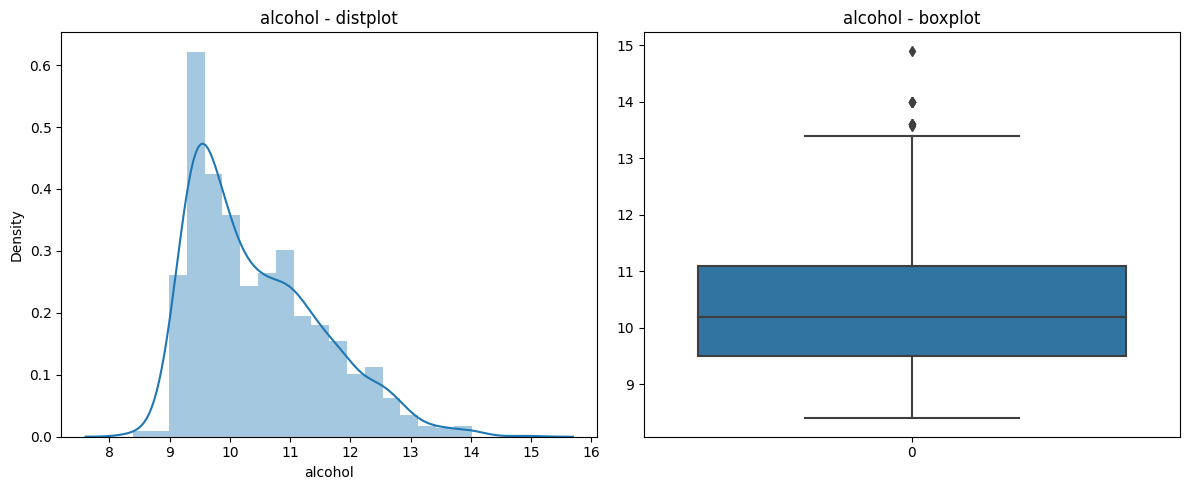

In [117]:
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

for index, i in enumerate(df.select_dtypes(include=["float64"]).columns):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    sns.distplot(df[i], ax=axes[0])
    axes[0].set_title(f"{i} - distplot")
    
    sns.boxplot(df[i], ax=axes[1])
    axes[1].set_title(f"{i} - boxplot")
    
    plt.tight_layout()
    plt.show()



<Axes: xlabel='quality', ylabel='count'>

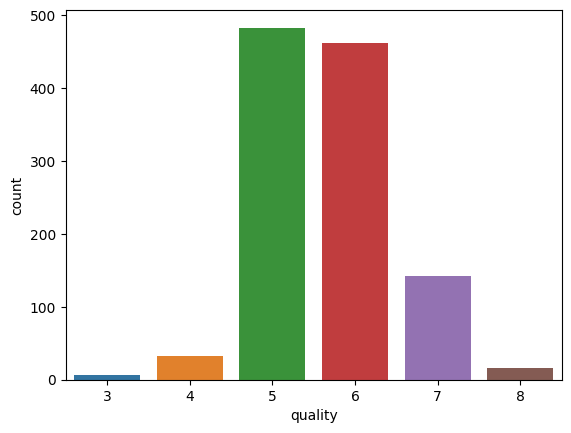

In [57]:
sns.countplot(data=df, x="quality")
# dane niezbalansowane, przeważają watości quality 2 i 3

In [58]:
# macierz korelacji cech
fig = px.imshow(df.corr())
fig.update_layout(height=600)
fig.show()

In [59]:
# Rozkład korelacji względem quality
df_corr_bar = df.corr().quality.sort_values()[:-1]
fig = px.bar(df_corr_bar, orientation="h")
fig.update_layout(showlegend=False)
fig.show()

In [121]:
# Korelacja pomiędzy Quality, a resztą atrybutów
import plotly.graph_objects as go

for col in columns:
    fig = go.Figure()
    
    for x in range(10):
        fig.add_trace(
            go.Box(
                x=df[df.quality == x][col],
                y=df[df.quality == x].quality,
                name="Quality " + str(x),
            )
        )

    fig.update_layout(yaxis_title="quality", xaxis_title=col)
    fig.update_traces(orientation="h")
    fig.show()

Feature Ranking - SelectKBest (f_classif):
fixed acidity: 2.0908485103454355
volatile acidity: 23.232921033330726
citric acid: 8.580872211771894
residual sugar: 0.5983884901184234
chlorides: 1.7885269341574355
free sulfur dioxide: 1.305048592809879
total sulfur dioxide: 7.400908972766169
density: 4.140994335772081
pH: 2.0111089506662174
sulphates: 8.747400603789005
alcohol: 40.10298136447275


Feature Ranking - SelectKBest (chi2):
fixed acidity: 0.4230927712617854
volatile acidity: 0.6538568359683479
citric acid: 0.643937396402222
residual sugar: 0.2424716371414169
chlorides: 0.025380268458447652
free sulfur dioxide: 4.869678036311884
total sulfur dioxide: 91.08216592242525
density: 8.326302676725566e-06
pH: 0.008215088323955108
sulphates: 0.20075224442152456
alcohol: 1.8504414729824983


Feature Ranking - SelectKBest (mutual_info):
fixed acidity: 9.240207866923834
volatile acidity: 15.343390381301203
citric acid: 7.7157796785768324
residual sugar: 1.4106371444154209
chlorides: 2.81226

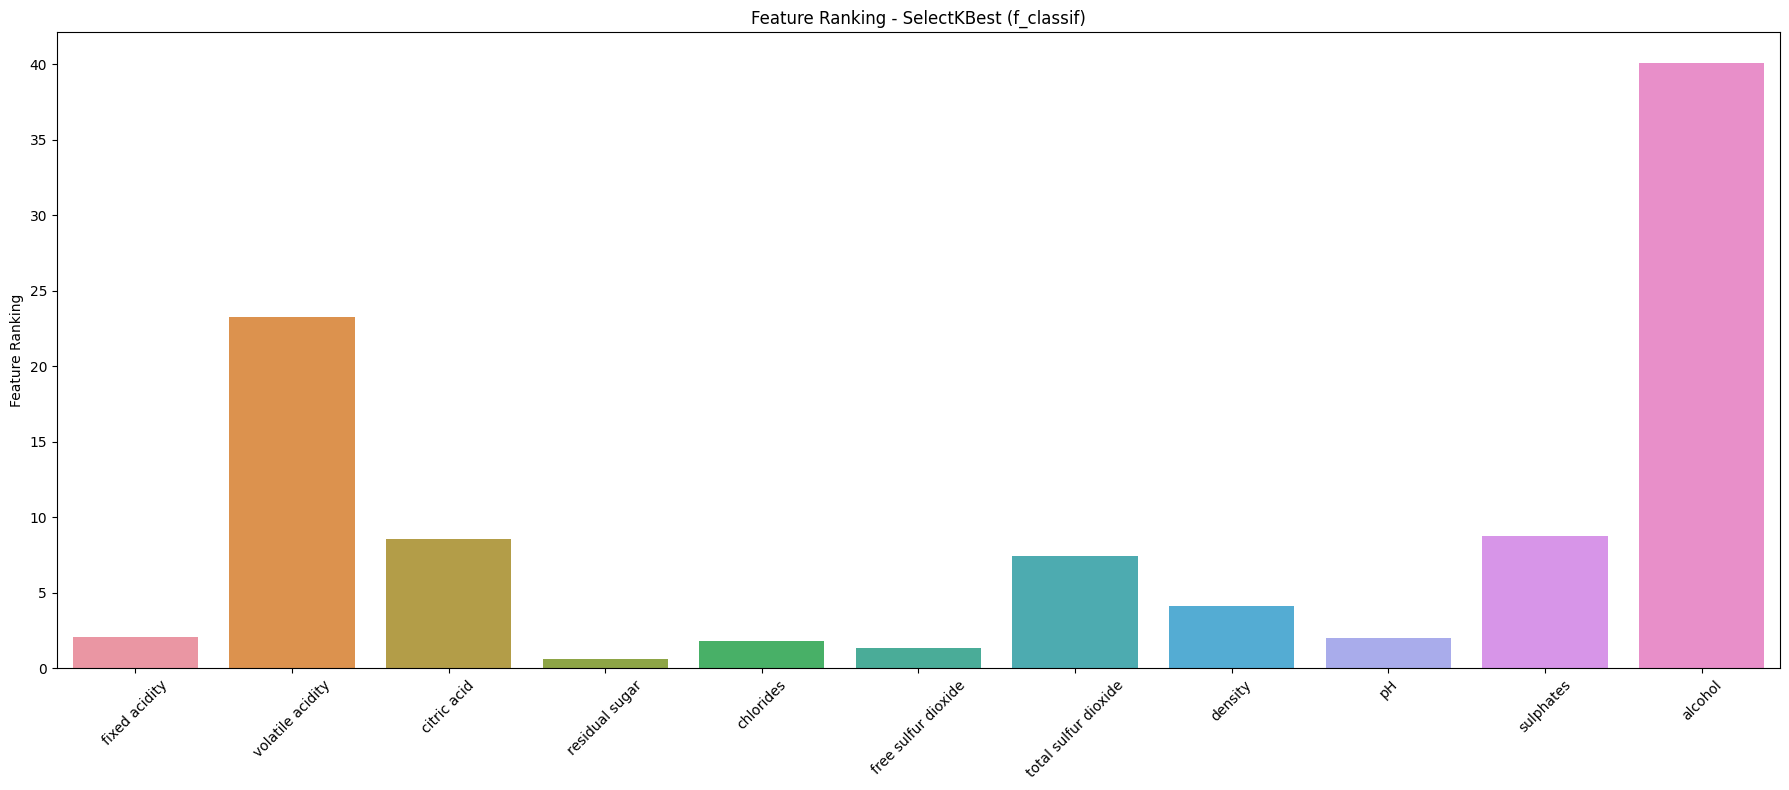

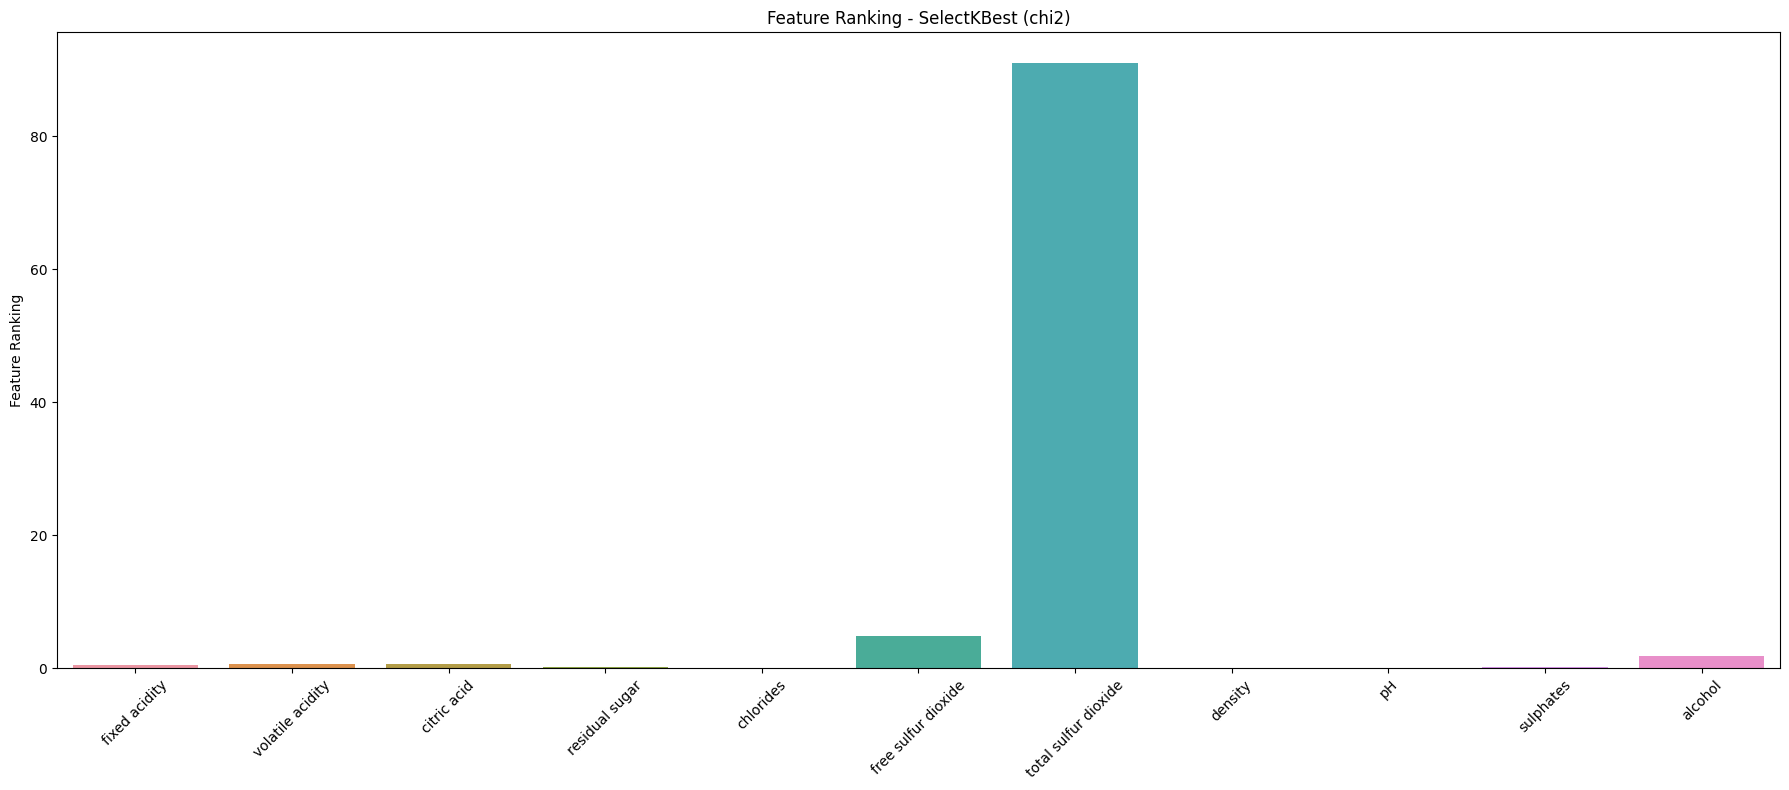

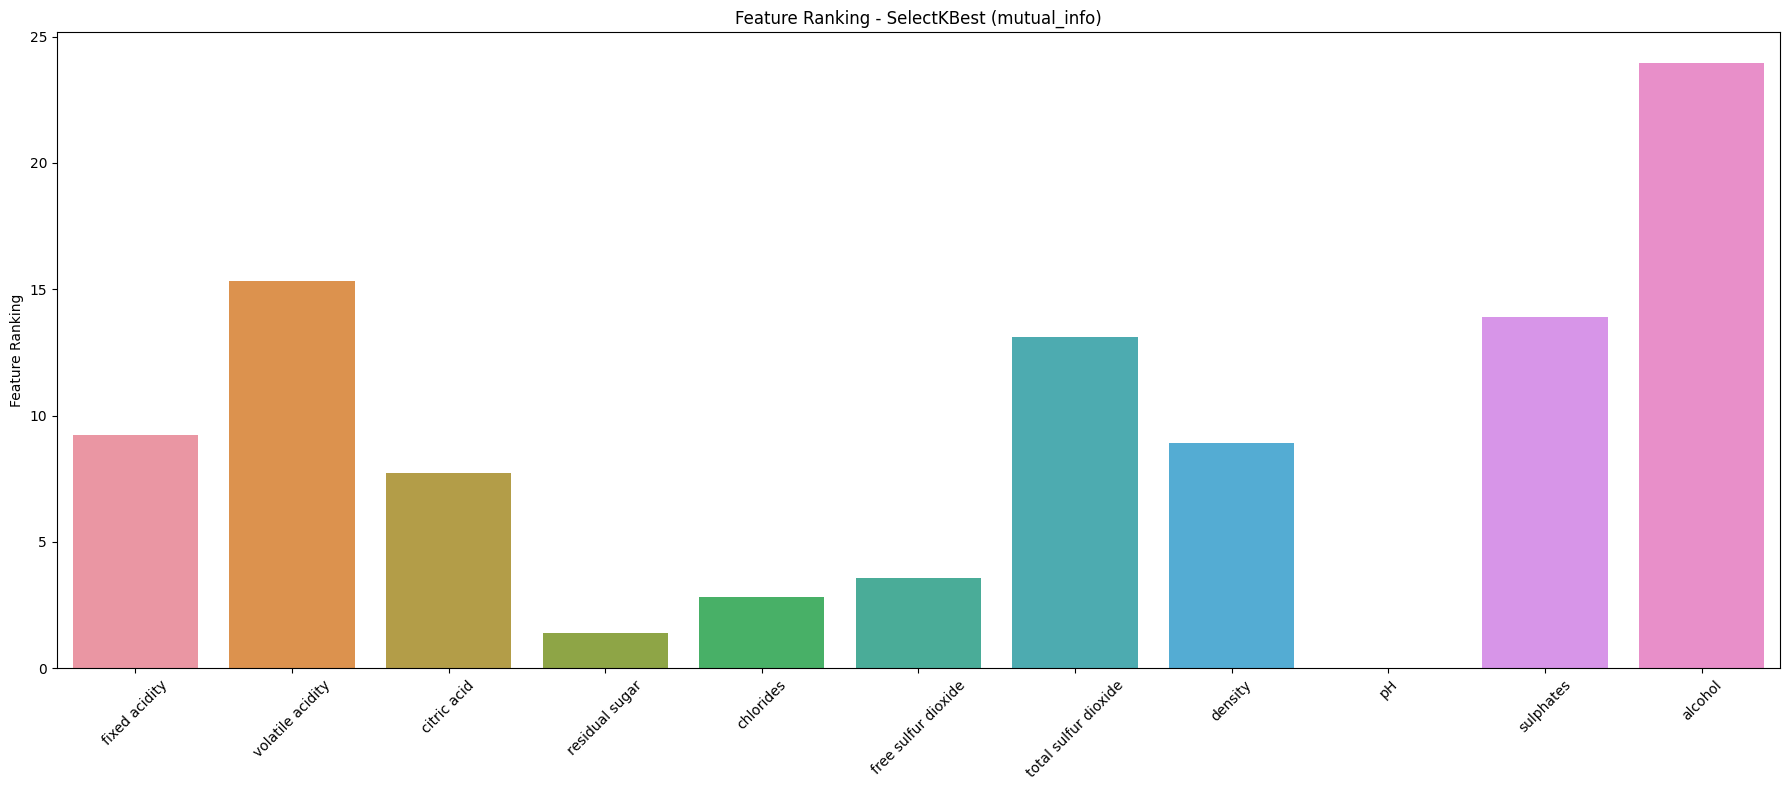

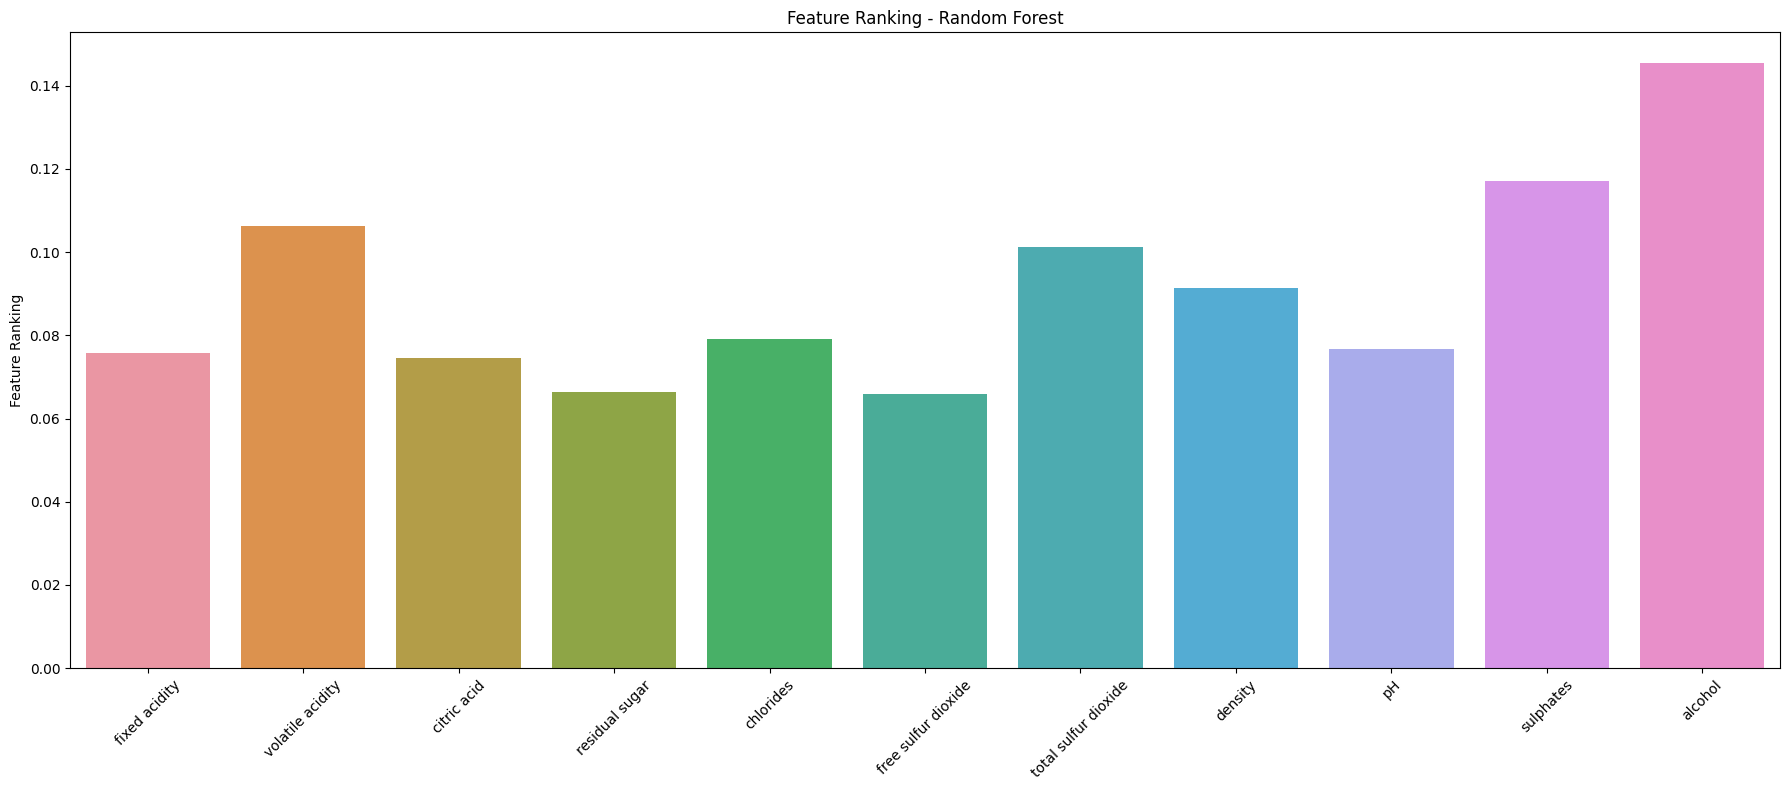

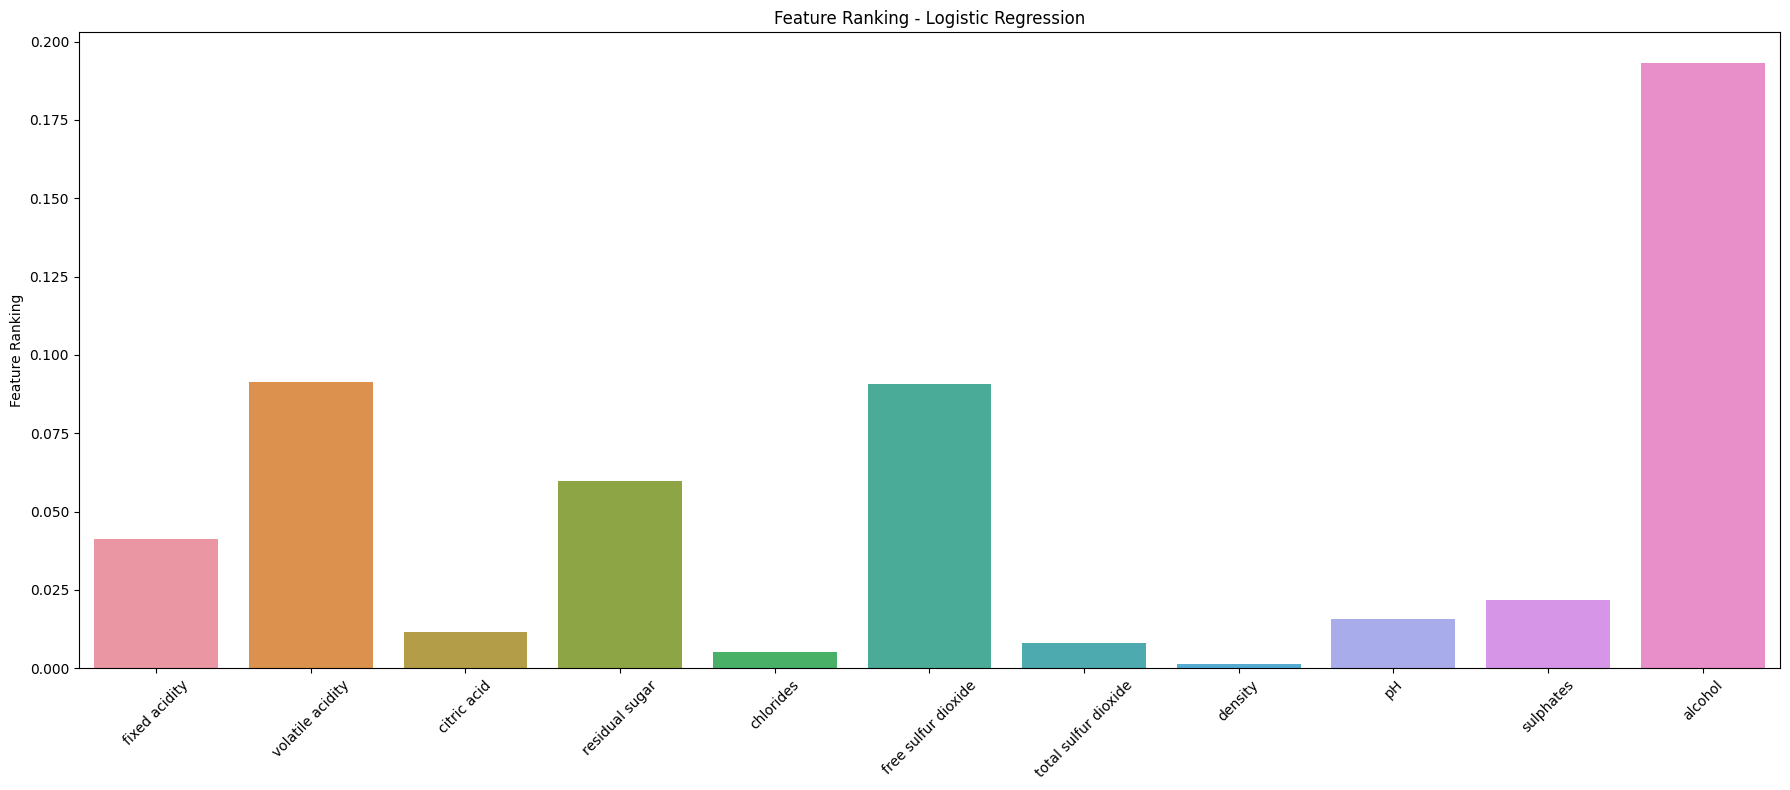

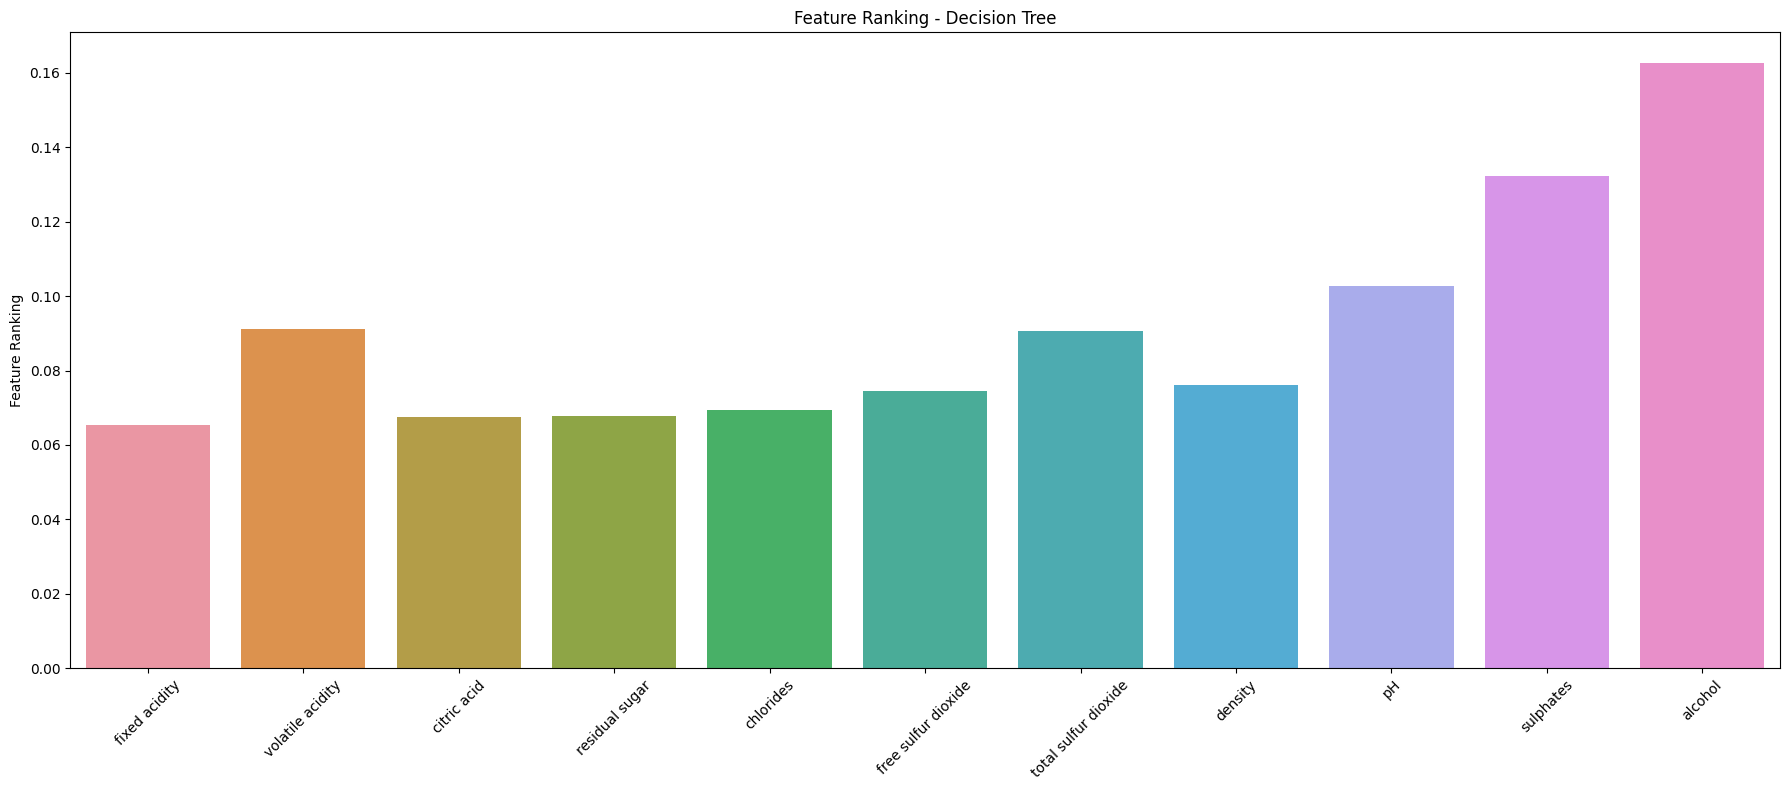

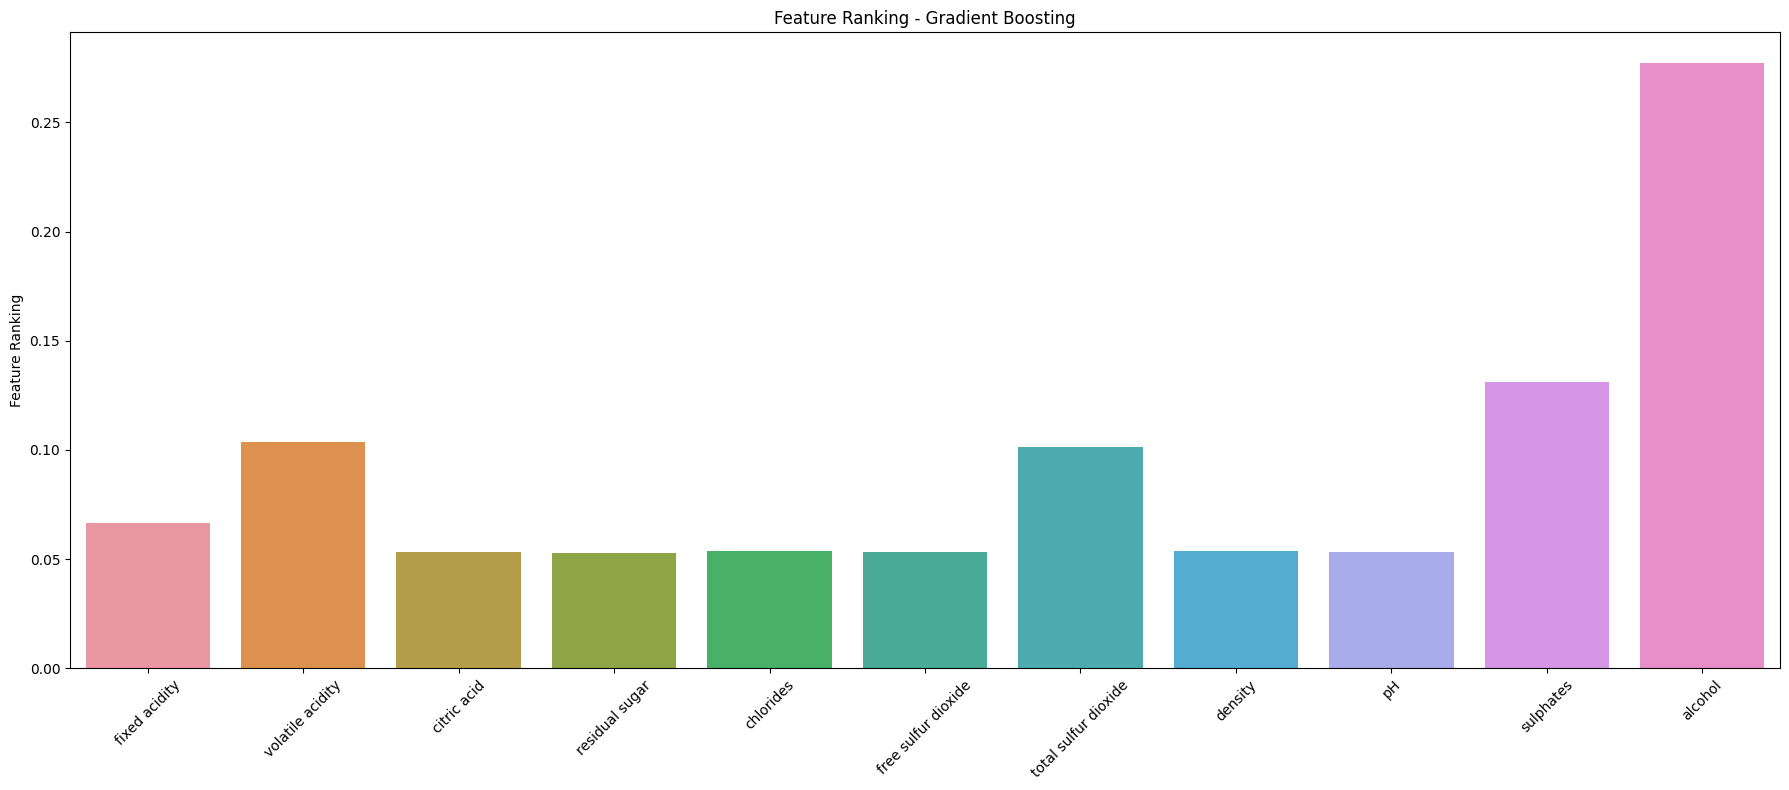

In [142]:
import matplotlib.pyplot as plt
import seaborn as sns

classifiers = {
    "SelectKBest (f_classif)": SelectKBest(score_func=f_classif, k="all"),
    "SelectKBest (chi2)": SelectKBest(score_func=chi2, k="all"),
    "SelectKBest (mutual_info)": SelectKBest(score_func=mutual_info_classif, k="all"),
    "Random Forest": RandomForestClassifier(),
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(),
    "Gradient Boosting": GradientBoostingClassifier()
}

rankings = {}

X = df.drop(["quality"], axis=1)
y = df["quality"]

for classifier_name, classifier in classifiers.items():
    if "SelectKBest" in classifier_name:
        classifier.fit(X, y)
        feature_contribution = (classifier.scores_ / sum(classifier.scores_)) * 100
        rankings[classifier_name] = {col: score for col, score in zip(X.columns, feature_contribution)}
    else:
        classifier.fit(X, y)
        if hasattr(classifier, "coef_"):
            importance = abs(classifier.coef_[0])
        else:
            importance = classifier.feature_importances_
        rankings[classifier_name] = {col: imp for col, imp in zip(X.columns, importance)}

metrics = [accuracy_score, roc_auc_score]

for method, ranking in rankings.items():
    print(f"Feature Ranking - {method}:")
    for feature, rank in ranking.items():
        print(f"{feature}: {rank}")
    print()

    if "SelectKBest" not in method:
        if len(set(y)) > 2:  # Sprawdzenie czy zadanie jest wieloklasowe
            metric = accuracy_score
        else:
            metric = roc_auc_score

        scores = []
        for classifier_name, classifier in classifiers.items():
            if method in classifier_name:
                predictions = classifier.predict(X)
                score = metric(y, predictions)
                scores.append(score)
        print(f"{metric.__name__} - {method}: {scores}")

    print()

# Tworzenie wykresów dla każdej metody osobno
for method, ranking in rankings.items():
    fig, ax = plt.subplots(figsize=(18, 8))
    sns.barplot(x=list(ranking.keys()), y=list(ranking.values()), ax=ax)
    ax.set_xticklabels(list(ranking.keys()), rotation=45)
    ax.set_ylabel("Feature Ranking")
    ax.set_title(f"Feature Ranking - {method}")

    plt.tight_layout()
    plt.show()


Feature Ranking - SelectKBest (f_classif):
fixed acidity: 2.0908485103454355
volatile acidity: 23.232921033330726
citric acid: 8.580872211771894
residual sugar: 0.5983884901184234
chlorides: 1.7885269341574355
free sulfur dioxide: 1.305048592809879
total sulfur dioxide: 7.400908972766169
density: 4.140994335772081
pH: 2.0111089506662174
sulphates: 8.747400603789005
alcohol: 40.10298136447275


Feature Ranking - SelectKBest (chi2):
fixed acidity: 0.4230927712617854
volatile acidity: 0.6538568359683479
citric acid: 0.643937396402222
residual sugar: 0.2424716371414169
chlorides: 0.025380268458447652
free sulfur dioxide: 4.869678036311884
total sulfur dioxide: 91.08216592242525
density: 8.326302676725566e-06
pH: 0.008215088323955108
sulphates: 0.20075224442152456
alcohol: 1.8504414729824983


Feature Ranking - SelectKBest (mutual_info):
fixed acidity: 8.108180584974923
volatile acidity: 13.740201763817705
citric acid: 7.990425565815978
residual sugar: 0.6371090020681078
chlorides: 0.628000

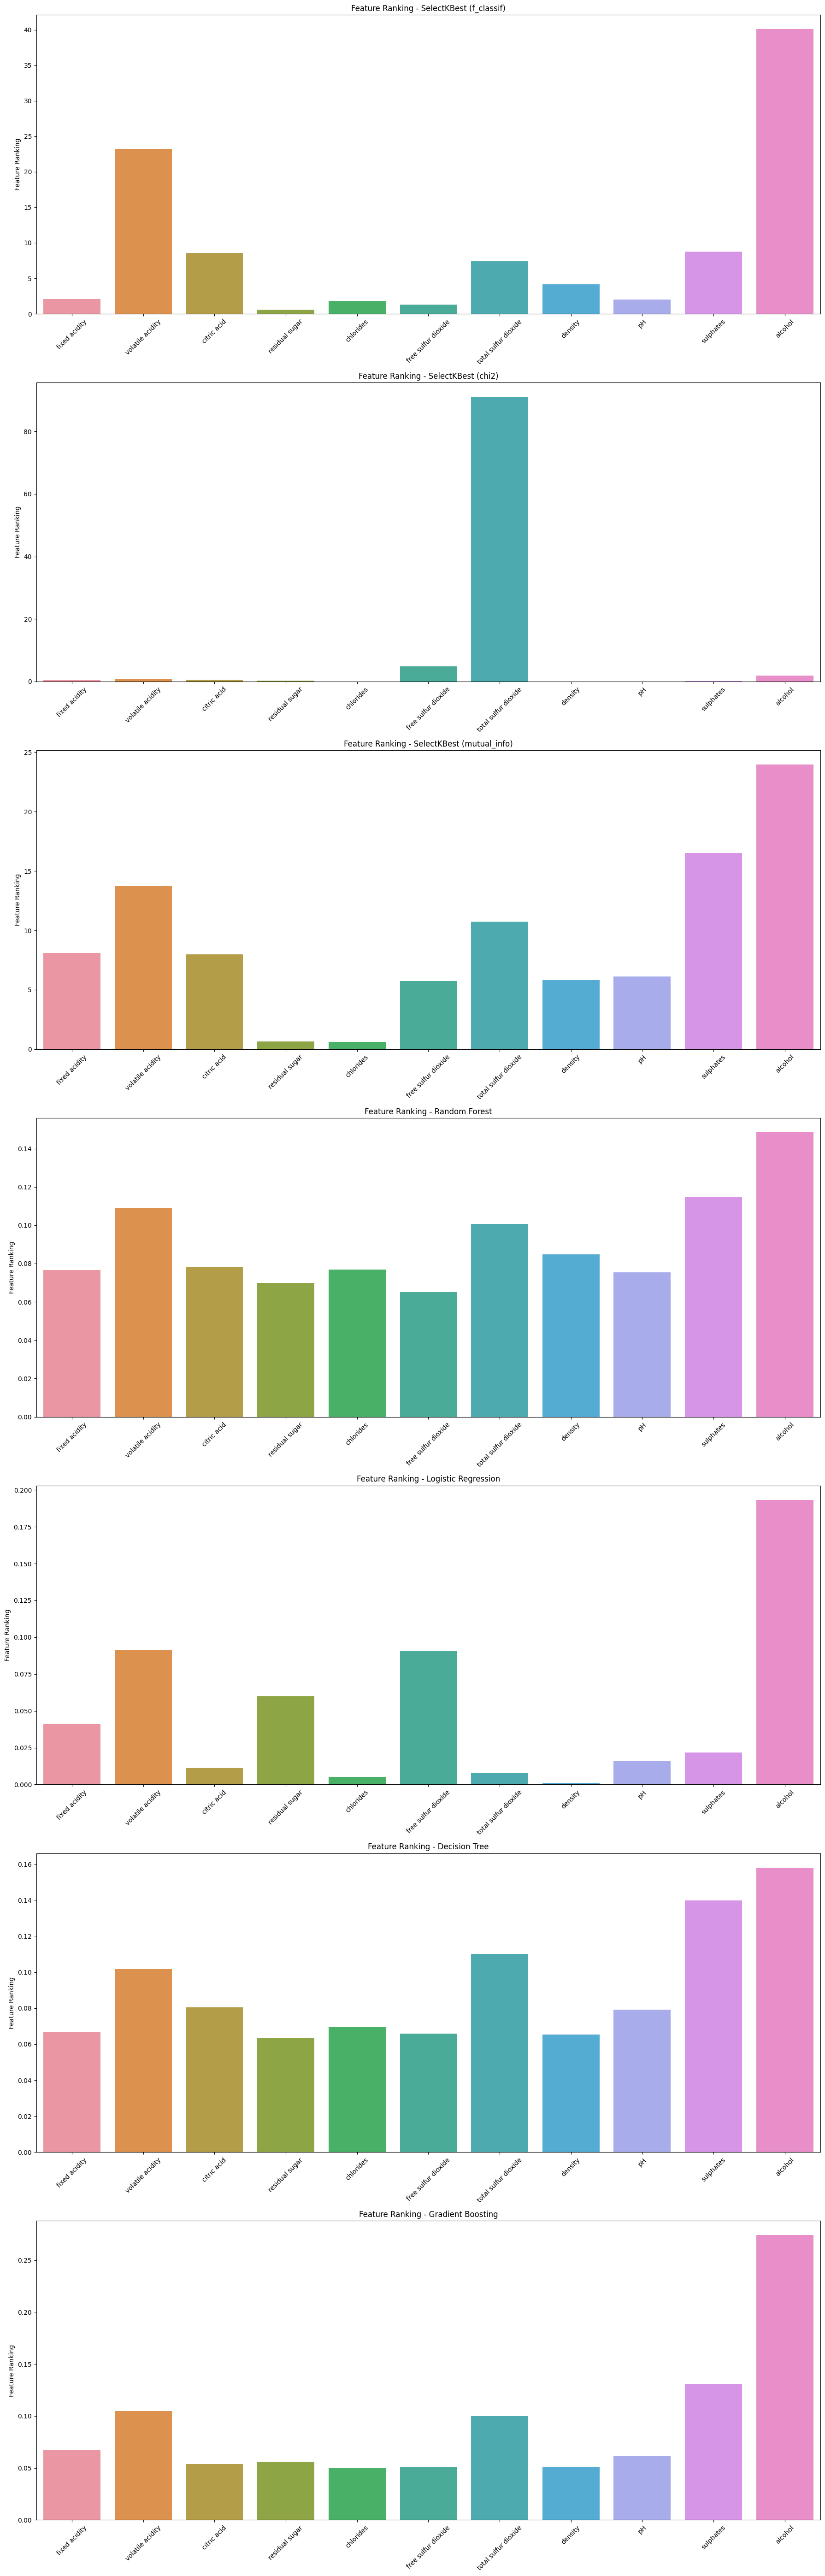

In [61]:
classifiers = {
    "SelectKBest (f_classif)": SelectKBest(score_func=f_classif, k="all"),
    "SelectKBest (chi2)": SelectKBest(score_func=chi2, k="all"),
    "SelectKBest (mutual_info)": SelectKBest(score_func=mutual_info_classif, k="all"),
    "Random Forest": RandomForestClassifier(),
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(),
    "Gradient Boosting": GradientBoostingClassifier()
}

rankings = {}

X = df.drop(["quality"], axis=1)
y = df["quality"]

for classifier_name, classifier in classifiers.items():
    if "SelectKBest" in classifier_name:
        classifier.fit(X, y)
        feature_contribution = (classifier.scores_ / sum(classifier.scores_)) * 100
        rankings[classifier_name] = {col: score for col, score in zip(X.columns, feature_contribution)}
    else:
        classifier.fit(X, y)
        if hasattr(classifier, "coef_"):
            importance = abs(classifier.coef_[0])
        else:
            importance = classifier.feature_importances_
        rankings[classifier_name] = {col: imp for col, imp in zip(X.columns, importance)}

metrics = [accuracy_score, roc_auc_score]

for method, ranking in rankings.items():
    print(f"Feature Ranking - {method}:")
    for feature, rank in ranking.items():
        print(f"{feature}: {rank}")
    print()

    if "SelectKBest" not in method:
        if len(set(y)) > 2:  # Sprawdzenie czy zadanie jest wieloklasowe
            metric = accuracy_score
        else:
            metric = roc_auc_score

        scores = []
        for classifier_name, classifier in classifiers.items():
            if method in classifier_name:
                predictions = classifier.predict(X)
                score = metric(y, predictions)
                scores.append(score)
        print(f"{metric.__name__} - {method}: {scores}")

    print()

fig, axes = plt.subplots(nrows=len(rankings), figsize=(18, 8 * len(rankings)))

for ax, (method, ranking) in zip(axes, rankings.items()):
    sns.barplot(x=list(ranking.keys()), y=list(ranking.values()), ax=ax)
    ax.set_xticklabels(list(ranking.keys()), rotation=45)
    ax.set_ylabel("Feature Ranking")
    ax.set_title(f"Feature Ranking - {method}")

plt.tight_layout()
plt.show()

In [122]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.25, random_state=0
)

In [63]:
oversample = RandomOverSampler(random_state=0)

In [123]:
X_train, y_train = oversample.fit_resample(X_train, y_train)

<Axes: xlabel='quality', ylabel='count'>

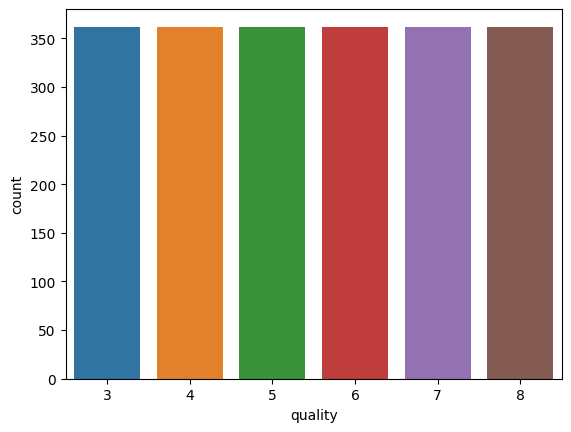

In [124]:
sns.countplot(data=X_train, x=y_train)

In [125]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Model: DecisionTreeClassifier(random_state=0)

              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.18      0.25      0.21         8
           5       0.71      0.66      0.69       121
           6       0.57      0.60      0.59       116
           7       0.46      0.44      0.45        36
           8       0.33      0.25      0.29         4

    accuracy                           0.59       286
   macro avg       0.38      0.37      0.37       286
weighted avg       0.60      0.59      0.59       286

------------------------------ 

Model: RandomForestClassifier(random_state=0)

              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.25      0.12      0.17         8
           5       0.72      0.81      0.76       121
           6       0.64      0.64      0.64       116
           7       0.43      0.33      0.38        36
     

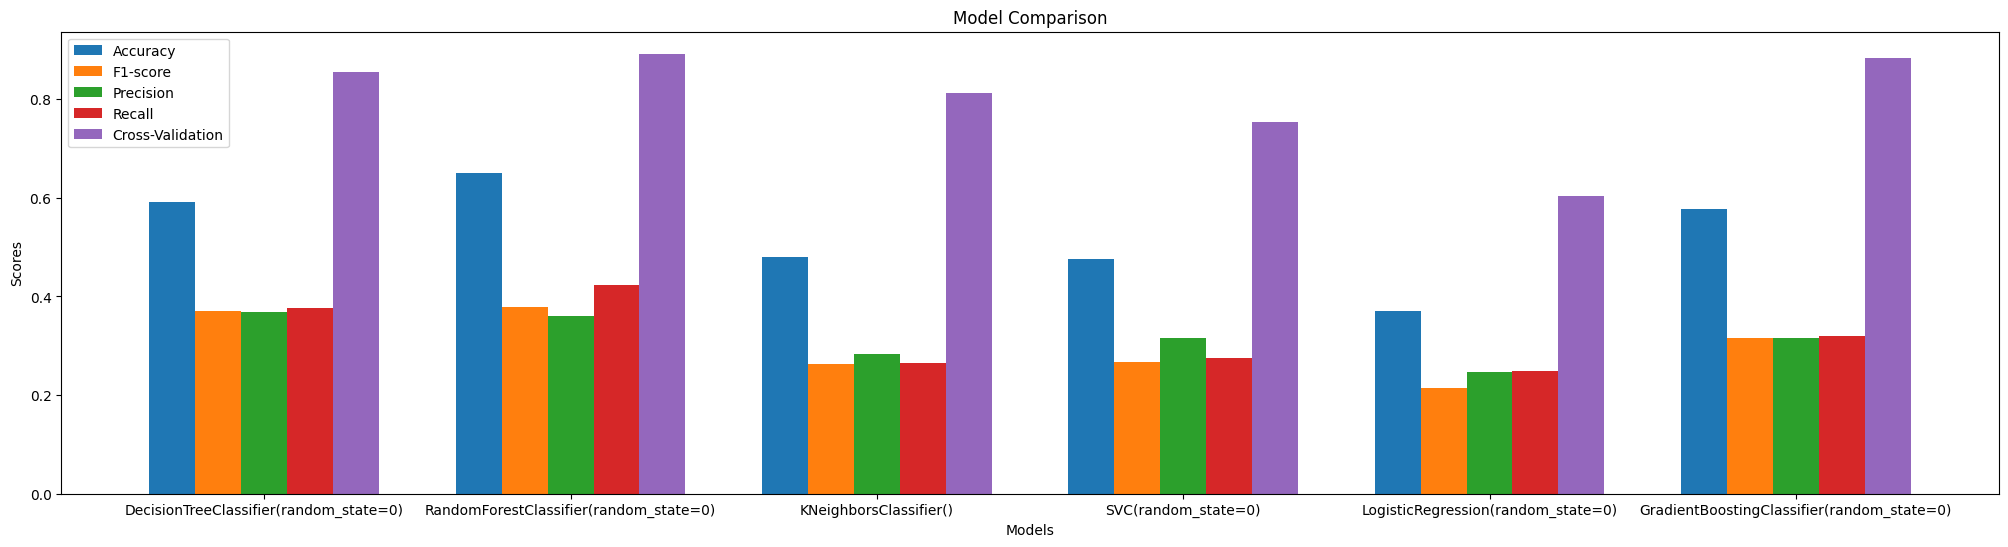


Results:
                                             Accuracy   F1-score  Precision   
DecisionTreeClassifier(random_state=0)      59.090909  36.990236  36.817496  \
RandomForestClassifier(random_state=0)      65.034965  37.923043  35.936362   
KNeighborsClassifier()                      47.902098  26.286109  28.309611   
SVC(random_state=0)                         47.552448  26.663681  31.497116   
LogisticRegression(random_state=0)          37.062937  21.390407  24.685729   
GradientBoostingClassifier(random_state=0)  57.692308  31.634543  31.641784   

                                               Recall  Cross-Validation  
DecisionTreeClassifier(random_state=0)      37.594763         85.406219  
RandomForestClassifier(random_state=0)      42.289636         89.227819  
KNeighborsClassifier()                      26.471732         81.169871  
SVC(random_state=0)                         27.589268         75.414905  
LogisticRegression(random_state=0)          24.907782         60.4

In [126]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.ensemble import GradientBoostingClassifier

models = [
    DecisionTreeClassifier(random_state=0),
    RandomForestClassifier(random_state=0),
    KNeighborsClassifier(),
    SVC(random_state=0),
    LogisticRegression(random_state=0),
    GradientBoostingClassifier(random_state=0)
]
models_comparison = {}

for model in models:
    print(f"Model: {str(model)}\n")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracies = cross_val_score(estimator=model, X=X_train, y=y_train, cv=5)
    print(classification_report(y_test, y_pred))
    print("-" * 30, "\n")
    models_comparison[f"{str(model)}"] = [
        accuracy_score(y_pred, y_test),
        f1_score(y_pred, y_test, average="macro"),
        precision_score(y_pred, y_test, average="macro"),
        recall_score(y_pred, y_test, average="macro"),
        (accuracies.mean()),
    ]
    
# Plotting comparative bar chart
labels = list(models_comparison.keys())
accuracy_scores = [val[0] for val in models_comparison.values()]
f1_scores = [val[1] for val in models_comparison.values()]
precision_scores = [val[2] for val in models_comparison.values()]
recall_scores = [val[3] for val in models_comparison.values()]
cross_val_scores = [val[4] for val in models_comparison.values()]

x = range(len(labels))
width = 0.15

plt.figure(figsize=(25, 6))

plt.bar(x, accuracy_scores, width, label='Accuracy')
plt.bar([val + width for val in x], f1_scores, width, label='F1-score')
plt.bar([val + 2 * width for val in x], precision_scores, width, label='Precision')
plt.bar([val + 3 * width for val in x], recall_scores, width, label='Recall')
plt.bar([val + 4 * width for val in x], cross_val_scores, width, label='Cross-Validation')

plt.xlabel('Models')
plt.ylabel('Scores')
plt.title('Model Comparison')
plt.xticks([val + 2 * width for val in x], labels)
plt.legend()

plt.show()

# Creating a DataFrame for results
results_df = pd.DataFrame(models_comparison.values(), index=models_comparison.keys(), columns=[
    'Accuracy', 'F1-score', 'Precision', 'Recall', 'Cross-Validation'
])

# Convert decimal scores to percentage
results_df *= 100

print("\nResults:")
print(results_df)



Model: DecisionTreeClassifier(random_state=0)

              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.18      0.25      0.21         8
           5       0.71      0.66      0.69       121
           6       0.57      0.60      0.59       116
           7       0.46      0.44      0.45        36
           8       0.33      0.25      0.29         4

    accuracy                           0.59       286
   macro avg       0.38      0.37      0.37       286
weighted avg       0.60      0.59      0.59       286

------------------------------ 

Model: RandomForestClassifier(random_state=0)

              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.25      0.12      0.17         8
           5       0.72      0.81      0.76       121
           6       0.64      0.64      0.64       116
           7       0.43      0.33      0.38        36
     

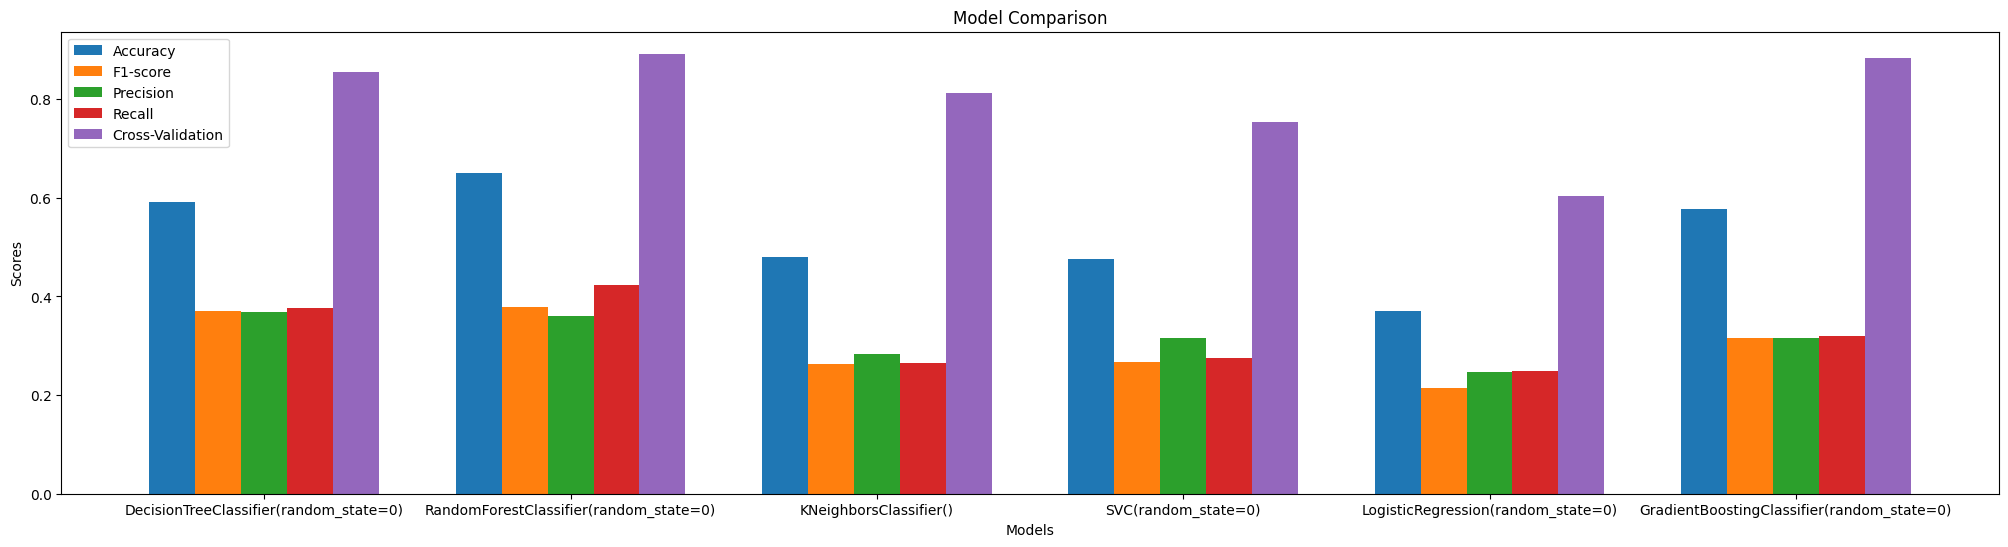


Results:
                                             Accuracy   F1-score  Precision   
DecisionTreeClassifier(random_state=0)      59.090909  36.990236  36.817496  \
RandomForestClassifier(random_state=0)      65.034965  37.923043  35.936362   
KNeighborsClassifier()                      47.902098  26.286109  28.309611   
SVC(random_state=0)                         47.552448  26.663681  31.497116   
LogisticRegression(random_state=0)          37.062937  21.390407  24.685729   
GradientBoostingClassifier(random_state=0)  57.692308  31.634543  31.641784   

                                               Recall  Cross-Validation   
DecisionTreeClassifier(random_state=0)      37.594763          0.854062  \
RandomForestClassifier(random_state=0)      42.289636          0.892278   
KNeighborsClassifier()                      26.471732          0.811699   
SVC(random_state=0)                         27.589268          0.754149   
LogisticRegression(random_state=0)          24.907782        

In [127]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.ensemble import GradientBoostingClassifier

models = [
    DecisionTreeClassifier(random_state=0),
    RandomForestClassifier(random_state=0),
    KNeighborsClassifier(),
    SVC(random_state=0),
    LogisticRegression(random_state=0),
    GradientBoostingClassifier(random_state=0)
]
models_comparison = {}

for model in models:
    print(f"Model: {str(model)}\n")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracies = cross_val_score(estimator=model, X=X_train, y=y_train, cv=5)
    print(classification_report(y_test, y_pred))
    print("-" * 30, "\n")
    models_comparison[f"{str(model)}"] = [
        accuracy_score(y_pred, y_test),
        f1_score(y_pred, y_test, average="macro"),
        precision_score(y_pred, y_test, average="macro"),
        recall_score(y_pred, y_test, average="macro"),
        (accuracies.mean()),
        (accuracies.std())  # Add standard deviation
    ]
    
# Plotting comparative bar chart
labels = list(models_comparison.keys())
accuracy_scores = [val[0] for val in models_comparison.values()]
f1_scores = [val[1] for val in models_comparison.values()]
precision_scores = [val[2] for val in models_comparison.values()]
recall_scores = [val[3] for val in models_comparison.values()]
cross_val_scores = [val[4] for val in models_comparison.values()]

x = range(len(labels))
width = 0.15

plt.figure(figsize=(25, 6))

plt.bar(x, accuracy_scores, width, label='Accuracy')
plt.bar([val + width for val in x], f1_scores, width, label='F1-score')
plt.bar([val + 2 * width for val in x], precision_scores, width, label='Precision')
plt.bar([val + 3 * width for val in x], recall_scores, width, label='Recall')
plt.bar([val + 4 * width for val in x], cross_val_scores, width, label='Cross-Validation')

plt.xlabel('Models')
plt.ylabel('Scores')
plt.title('Model Comparison')
plt.xticks([val + 2 * width for val in x], labels)
plt.legend()

plt.show()

# Creating a DataFrame for results
results_df = pd.DataFrame(models_comparison.values(), index=models_comparison.keys(), columns=[
    'Accuracy', 'F1-score', 'Precision', 'Recall', 'Cross-Validation', 'Std Deviation'
])

# Convert decimal scores to percentage
results_df[['Accuracy', 'F1-score', 'Precision', 'Recall']] *= 100

print("\nResults:")
print(results_df)


In [69]:
models_comparison = {}

In [70]:
parameters = {
    "max_depth": range(5, 26),
}

model = DecisionTreeClassifier(random_state=0)

clf = GridSearchCV(model, parameters, n_jobs=-1)
print("Searching for best hyperparameters...")
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

model = DecisionTreeClassifier(random_state=0, **clf.best_params_)

accuracies = cross_val_score(estimator=model, X=X_train, y=y_train, cv=5)
models_comparison["DecisionTreeClassifier"] = [
    accuracy_score(y_pred, y_test),
    f1_score(y_pred, y_test, average="macro"),
    precision_score(y_pred, y_test, average="macro"),
    recall_score(y_pred, y_test, average="macro"),
    (accuracies.mean()),
]

results_df = pd.DataFrame(clf.cv_results_)
results_df[["params", "mean_test_score"]].sort_values(
    "mean_test_score", ascending=False
).head(10)

Searching for best hyperparameters...


,params,mean_test_score
16,{'max_depth': 21},0.854982
10,{'max_depth': 15},0.854979
11,{'max_depth': 16},0.854062
19,{'max_depth': 24},0.854062
18,{'max_depth': 23},0.854062
17,{'max_depth': 22},0.854062
15,{'max_depth': 20},0.854062
13,{'max_depth': 18},0.854062
12,{'max_depth': 17},0.854062
20,{'max_depth': 25},0.854062


In [71]:
parameters = {
    "n_estimators": [250, 500, 750, 1000],
    "max_depth": [16, 18, 20, 24, 26, 28, 30],
}

model = RandomForestClassifier(random_state=0)

clf = GridSearchCV(model, parameters, n_jobs=-1)
print("Searching for best hyperparameters...")
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

model = RandomForestClassifier(random_state=0, **clf.best_params_)

accuracies = cross_val_score(estimator=model, X=X_train, y=y_train, cv=5)
models_comparison["RandomForestClassifier"] = [
    accuracy_score(y_pred, y_test),
    f1_score(y_pred, y_test, average="macro"),
    precision_score(y_pred, y_test, average="macro"),
    recall_score(y_pred, y_test, average="macro"),
    (accuracies.mean()),
]

results_df = pd.DataFrame(clf.cv_results_)
results_df[["params", "mean_test_score"]].sort_values(
    "mean_test_score", ascending=False
).head(10)

Searching for best hyperparameters...


,params,mean_test_score
4,"{'max_depth': 18, 'n_estimators': 250}",0.890894
0,"{'max_depth': 16, 'n_estimators': 250}",0.890432
8,"{'max_depth': 20, 'n_estimators': 250}",0.890432
1,"{'max_depth': 16, 'n_estimators': 500}",0.890431
26,"{'max_depth': 30, 'n_estimators': 750}",0.889973
22,"{'max_depth': 28, 'n_estimators': 750}",0.889973
18,"{'max_depth': 26, 'n_estimators': 750}",0.889973
10,"{'max_depth': 20, 'n_estimators': 750}",0.889973
14,"{'max_depth': 24, 'n_estimators': 750}",0.889973
6,"{'max_depth': 18, 'n_estimators': 750}",0.889512


In [72]:
parameters = {
    "n_neighbors": range(5, 50, 5),
    "weights": ["uniform", "distance"],
}

model = KNeighborsClassifier()

clf = GridSearchCV(model, parameters, n_jobs=-1)
print("Searching for best hyperparameters...")
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

model = KNeighborsClassifier(**clf.best_params_)

accuracies = cross_val_score(estimator=model, X=X_train, y=y_train, cv=5)
models_comparison["KNeighborsClassifier"] = [
    accuracy_score(y_pred, y_test),
    f1_score(y_pred, y_test, average="macro"),
    precision_score(y_pred, y_test, average="macro"),
    recall_score(y_pred, y_test, average="macro"),
    (accuracies.mean()),
]

results_df = pd.DataFrame(clf.cv_results_)
results_df[["params", "mean_test_score"]].sort_values(
    "mean_test_score", ascending=False
).head(10)

Searching for best hyperparameters...


,params,mean_test_score
1,"{'n_neighbors': 5, 'weights': 'distance'}",0.860047
3,"{'n_neighbors': 10, 'weights': 'distance'}",0.845319
5,"{'n_neighbors': 15, 'weights': 'distance'}",0.836119
15,"{'n_neighbors': 40, 'weights': 'distance'}",0.831971
13,"{'n_neighbors': 35, 'weights': 'distance'}",0.830592
17,"{'n_neighbors': 45, 'weights': 'distance'}",0.830587
7,"{'n_neighbors': 20, 'weights': 'distance'}",0.829666
9,"{'n_neighbors': 25, 'weights': 'distance'}",0.828744
11,"{'n_neighbors': 30, 'weights': 'distance'}",0.828285
0,"{'n_neighbors': 5, 'weights': 'uniform'}",0.811699


In [73]:
parameters = {
    "C": np.arange(0.1, 1, 0.2),
    "kernel": ["linear", "poly", "rbf", "sigmoid"],
}

model = SVC(random_state=0)

clf = GridSearchCV(model, parameters, n_jobs=-1)
print("Searching for best hyperparameters...")
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

model = SVC(random_state=0, **clf.best_params_)

accuracies = cross_val_score(estimator=model, X=X_train, y=y_train, cv=5)
models_comparison["SVC"] = [
    accuracy_score(y_pred, y_test),
    f1_score(y_pred, y_test, average="macro"),
    precision_score(y_pred, y_test, average="macro"),
    recall_score(y_pred, y_test, average="macro"),
    (accuracies.mean()),
]

results_df = pd.DataFrame(clf.cv_results_)
results_df[["params", "mean_test_score"]].sort_values(
    "mean_test_score", ascending=False
).head(10)

Searching for best hyperparameters...


,params,mean_test_score
18,"{'C': 0.9000000000000001, 'kernel': 'rbf'}",0.752769
14,"{'C': 0.7000000000000001, 'kernel': 'rbf'}",0.731125
10,"{'C': 0.5000000000000001, 'kernel': 'rbf'}",0.715004
17,"{'C': 0.9000000000000001, 'kernel': 'poly'}",0.700743
6,"{'C': 0.30000000000000004, 'kernel': 'rbf'}",0.700737
13,"{'C': 0.7000000000000001, 'kernel': 'poly'}",0.679572
16,"{'C': 0.9000000000000001, 'kernel': 'linear'}",0.642271
12,"{'C': 0.7000000000000001, 'kernel': 'linear'}",0.640426
9,"{'C': 0.5000000000000001, 'kernel': 'poly'}",0.639971
8,"{'C': 0.5000000000000001, 'kernel': 'linear'}",0.636737


In [74]:
parameters = {
    "C": np.arange(0.1, 1, 0.2),
    "solver": ["newton-cg", "lbfgs", "liblinear", "sag", "saga"],
}

model = LogisticRegression(random_state=0, max_iter=100000)

clf = GridSearchCV(model, parameters, n_jobs=-1)
print("Searching for best hyperparameters...")
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

model = LogisticRegression(random_state=0, max_iter=100000, **clf.best_params_)

accuracies = cross_val_score(estimator=model, X=X_train, y=y_train, cv=5)
models_comparison["LogisticRegression"] = [
    accuracy_score(y_pred, y_test),
    f1_score(y_pred, y_test, average="macro"),
    precision_score(y_pred, y_test, average="macro"),
    recall_score(y_pred, y_test, average="macro"),
    (accuracies.mean()),
]

results_df = pd.DataFrame(clf.cv_results_)
results_df[["params", "mean_test_score"]].sort_values(
    "mean_test_score", ascending=False
).head(10)

Searching for best hyperparameters...


,params,mean_test_score
24,"{'C': 0.9000000000000001, 'solver': 'saga'}",0.604053
23,"{'C': 0.9000000000000001, 'solver': 'sag'}",0.604053
21,"{'C': 0.9000000000000001, 'solver': 'lbfgs'}",0.604053
20,"{'C': 0.9000000000000001, 'solver': 'newton-cg'}",0.604053
1,"{'C': 0.1, 'solver': 'lbfgs'}",0.600833
0,"{'C': 0.1, 'solver': 'newton-cg'}",0.600833
3,"{'C': 0.1, 'solver': 'sag'}",0.600833
4,"{'C': 0.1, 'solver': 'saga'}",0.600833
15,"{'C': 0.7000000000000001, 'solver': 'newton-cg'}",0.598072
16,"{'C': 0.7000000000000001, 'solver': 'lbfgs'}",0.598072


In [75]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV

parameters = {
    'n_estimators': [200, 300, 500],
    'learning_rate': [0.1, 0.01, 0.001],
    'max_depth': [7, 11, 13, 15],
}
model = GradientBoostingClassifier(random_state=0)

clf = GridSearchCV(model, parameters, n_jobs=-1)
print("Searching for best hyperparameters...")
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

model = GradientBoostingClassifier(random_state=0, **clf.best_params_)

accuracies = cross_val_score(estimator=model, X=X_train, y=y_train, cv=5)
models_comparison["GradientBoostingClassifier"] = [
    accuracy_score(y_pred, y_test),
    f1_score(y_pred, y_test, average="macro"),
    precision_score(y_pred, y_test, average="macro"),
    recall_score(y_pred, y_test, average="macro"),
    (accuracies.mean()),
]

results_df = pd.DataFrame(clf.cv_results_)
results_df[["params", "mean_test_score"]].sort_values(
    "mean_test_score", ascending=False
).head(10)


Searching for best hyperparameters...


,params,mean_test_score
0,"{'learning_rate': 0.1, 'max_depth': 7, 'n_esti...",0.900097
1,"{'learning_rate': 0.1, 'max_depth': 7, 'n_esti...",0.897799
2,"{'learning_rate': 0.1, 'max_depth': 7, 'n_esti...",0.894574
14,"{'learning_rate': 0.01, 'max_depth': 7, 'n_est...",0.893658
13,"{'learning_rate': 0.01, 'max_depth': 7, 'n_est...",0.891811
3,"{'learning_rate': 0.1, 'max_depth': 11, 'n_est...",0.890895
4,"{'learning_rate': 0.1, 'max_depth': 11, 'n_est...",0.890895
5,"{'learning_rate': 0.1, 'max_depth': 11, 'n_est...",0.890895
12,"{'learning_rate': 0.01, 'max_depth': 7, 'n_est...",0.884908
17,"{'learning_rate': 0.01, 'max_depth': 11, 'n_es...",0.883069


Model: DecisionTreeClassifier(max_depth=21, random_state=0)

              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.18      0.25      0.21         8
           5       0.71      0.66      0.69       121
           6       0.57      0.60      0.59       116
           7       0.46      0.44      0.45        36
           8       0.33      0.25      0.29         4

    accuracy                           0.59       286
   macro avg       0.38      0.37      0.37       286
weighted avg       0.60      0.59      0.59       286

------------------------------ 

Model: RandomForestClassifier(max_depth=18, n_estimators=250, random_state=0)

              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.25      0.12      0.17         8
           5       0.73      0.81      0.77       121
           6       0.64      0.64      0.64       116
           7 

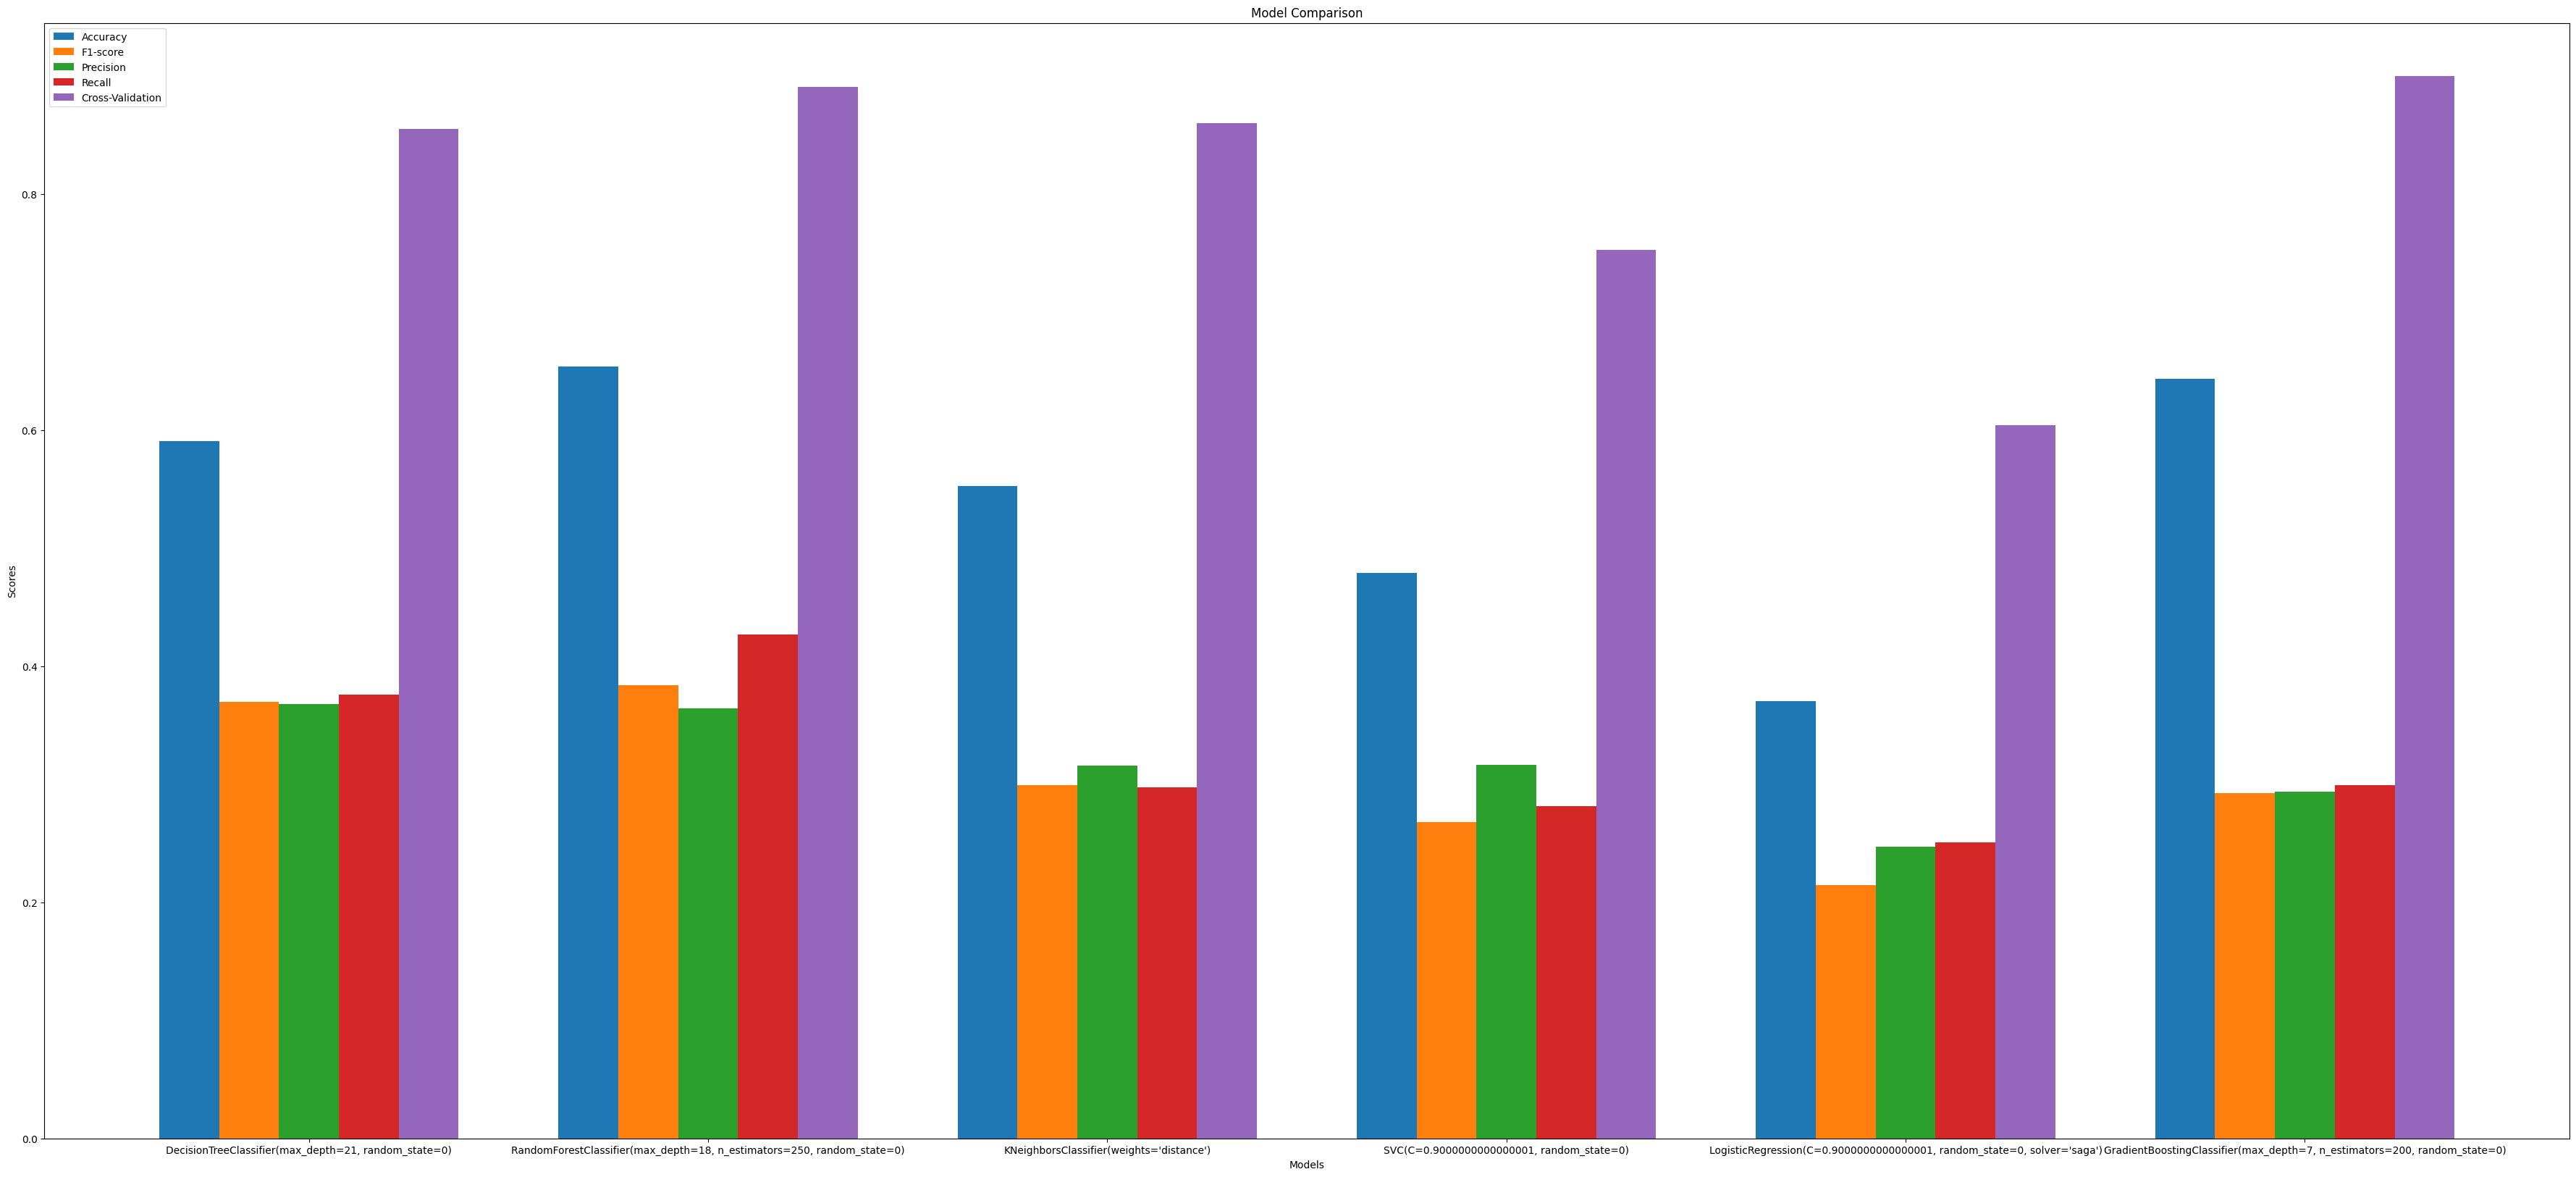


Results:
                                                     Accuracy   F1-score   
DecisionTreeClassifier(max_depth=21, random_sta...  59.090909  36.990236  \
RandomForestClassifier(max_depth=18, n_estimato...  65.384615  38.392601   
KNeighborsClassifier(weights='distance')            55.244755  29.945729   
SVC(C=0.9000000000000001, random_state=0)           47.902098  26.807344   
LogisticRegression(C=0.9000000000000001, random...  37.062937  21.439028   
GradientBoostingClassifier(max_depth=7, n_estim...  64.335664  29.270138   

                                                    Precision     Recall   
DecisionTreeClassifier(max_depth=21, random_sta...  36.817496  37.594763  \
RandomForestClassifier(max_depth=18, n_estimato...  36.399325  42.702214   
KNeighborsClassifier(weights='distance')            31.580829  29.724003   
SVC(C=0.9000000000000001, random_state=0)           31.640794  28.152100   
LogisticRegression(C=0.9000000000000001, random...  24.685729  25.053603   
G

In [131]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.ensemble import GradientBoostingClassifier

models = [
    DecisionTreeClassifier(random_state=0, max_depth=21),
    RandomForestClassifier(random_state=0, max_depth=18, n_estimators=250),
    KNeighborsClassifier(n_neighbors=5, weights='distance'),
    SVC(random_state=0, C=0.9000000000000001, kernel='rbf'),
    LogisticRegression(random_state=0, C=0.9000000000000001, solver='saga'),
    GradientBoostingClassifier(random_state=0, learning_rate=0.1, max_depth=7, n_estimators=200)
]
models_comparison = {}

for model in models:
    print(f"Model: {str(model)}\n")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracies = cross_val_score(estimator=model, X=X_train, y=y_train, cv=5)
    print(classification_report(y_test, y_pred))
    print("-" * 30, "\n")
    models_comparison[f"{str(model)}"] = [
        accuracy_score(y_pred, y_test),
        f1_score(y_pred, y_test, average="macro"),
        precision_score(y_pred, y_test, average="macro"),
        recall_score(y_pred, y_test, average="macro"),
        (accuracies.mean()),
        (accuracies.std())  # Add standard deviation
    ]
    
# Plotting comparative bar chart
labels = list(models_comparison.keys())
accuracy_scores = [val[0] for val in models_comparison.values()]
f1_scores = [val[1] for val in models_comparison.values()]
precision_scores = [val[2] for val in models_comparison.values()]
recall_scores = [val[3] for val in models_comparison.values()]
cross_val_scores = [val[4] for val in models_comparison.values()]

x = range(len(labels))
width = 0.15

plt.figure(figsize=(45, 20))

plt.bar(x, accuracy_scores, width, label='Accuracy')
plt.bar([val + width for val in x], f1_scores, width, label='F1-score')
plt.bar([val + 2 * width for val in x], precision_scores, width, label='Precision')
plt.bar([val + 3 * width for val in x], recall_scores, width, label='Recall')
plt.bar([val + 4 * width for val in x], cross_val_scores, width, label='Cross-Validation')

plt.xlabel('Models')
plt.ylabel('Scores')
plt.title('Model Comparison')
plt.xticks([val + 2 * width for val in x], labels)
plt.legend()

plt.show()

# Creating a DataFrame for results
results_df = pd.DataFrame(models_comparison.values(), index=models_comparison.keys(), columns=[
    'Accuracy', 'F1-score', 'Precision', 'Recall', 'Cross-Validation', 'Std Deviation'
])

# Convert decimal scores to percentage
results_df[['Accuracy', 'F1-score', 'Precision', 'Recall']] *= 100

print("\nResults:")
print(results_df)

In [132]:
X_fs = X[
    [
        "volatile acidity",
        "citric acid",
        "total sulfur dioxide",
        "sulphates",
        "alcohol",
    ]
]

In [133]:
X_train, X_test, y_train, y_test = train_test_split(
    X_fs, y, stratify=y, test_size=0.25, random_state=0
)

In [134]:
X_train, X_test, y_train, y_test = train_test_split(
    X_fs, y, stratify=y, test_size=0.25, random_state=0
)

In [98]:
oversample = RandomOverSampler(random_state=0)

In [135]:
X_train, y_train = oversample.fit_resample(X_train, y_train)

<Axes: xlabel='quality', ylabel='count'>

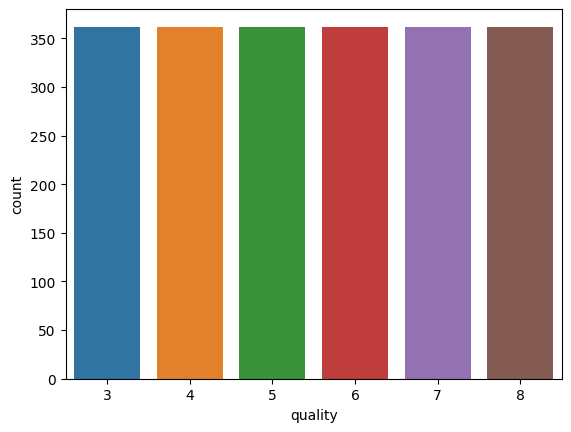

In [136]:
sns.countplot(data=X_train, x=y_train)

In [137]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Model: DecisionTreeClassifier(random_state=0)

              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.18      0.25      0.21         8
           5       0.70      0.71      0.70       121
           6       0.58      0.53      0.56       116
           7       0.34      0.39      0.36        36
           8       0.00      0.00      0.00         4

    accuracy                           0.57       286
   macro avg       0.30      0.31      0.31       286
weighted avg       0.58      0.57      0.58       286

------------------------------ 

Model: RandomForestClassifier(random_state=0)

              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.20      0.12      0.15         8
           5       0.72      0.82      0.77       121
           6       0.63      0.59      0.61       116
           7       0.36      0.33      0.35        36
     

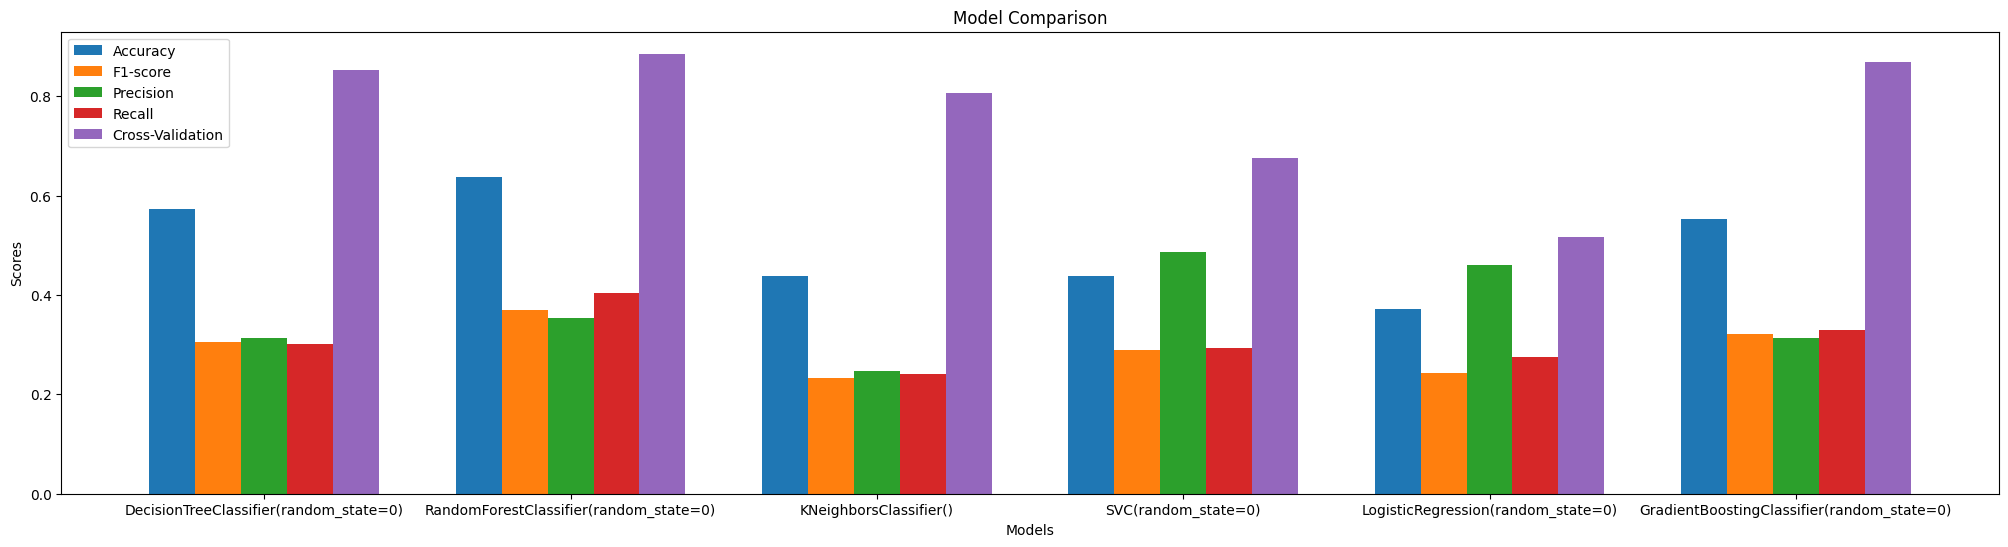


Results:
                                             Accuracy   F1-score  Precision   
DecisionTreeClassifier(random_state=0)      57.342657  30.585575  31.401924  \
RandomForestClassifier(random_state=0)      63.636364  36.929679  35.355712   
KNeighborsClassifier()                      43.706294  23.303466  24.604258   
SVC(random_state=0)                         43.706294  28.879852  48.722333   
LogisticRegression(random_state=0)          37.062937  24.288075  46.045882   
GradientBoostingClassifier(random_state=0)  55.244755  32.050716  31.357726   

                                               Recall  Cross-Validation  
DecisionTreeClassifier(random_state=0)      30.031797         85.313841  
RandomForestClassifier(random_state=0)      40.321527         88.583082  
KNeighborsClassifier()                      24.038744         80.572594  
SVC(random_state=0)                         29.346034         67.542031  
LogisticRegression(random_state=0)          27.433725         51.6

In [138]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.ensemble import GradientBoostingClassifier

models = [
    DecisionTreeClassifier(random_state=0),
    RandomForestClassifier(random_state=0),
    KNeighborsClassifier(),
    SVC(random_state=0),
    LogisticRegression(random_state=0),
    GradientBoostingClassifier(random_state=0)
]
models_comparison = {}

for model in models:
    print(f"Model: {str(model)}\n")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracies = cross_val_score(estimator=model, X=X_train, y=y_train, cv=5)
    print(classification_report(y_test, y_pred))
    print("-" * 30, "\n")
    models_comparison[f"{str(model)}"] = [
        accuracy_score(y_pred, y_test),
        f1_score(y_pred, y_test, average="macro"),
        precision_score(y_pred, y_test, average="macro"),
        recall_score(y_pred, y_test, average="macro"),
        (accuracies.mean()),
    ]
    
# Plotting comparative bar chart
labels = list(models_comparison.keys())
accuracy_scores = [val[0] for val in models_comparison.values()]
f1_scores = [val[1] for val in models_comparison.values()]
precision_scores = [val[2] for val in models_comparison.values()]
recall_scores = [val[3] for val in models_comparison.values()]
cross_val_scores = [val[4] for val in models_comparison.values()]

x = range(len(labels))
width = 0.15

plt.figure(figsize=(25, 6))

plt.bar(x, accuracy_scores, width, label='Accuracy')
plt.bar([val + width for val in x], f1_scores, width, label='F1-score')
plt.bar([val + 2 * width for val in x], precision_scores, width, label='Precision')
plt.bar([val + 3 * width for val in x], recall_scores, width, label='Recall')
plt.bar([val + 4 * width for val in x], cross_val_scores, width, label='Cross-Validation')

plt.xlabel('Models')
plt.ylabel('Scores')
plt.title('Model Comparison')
plt.xticks([val + 2 * width for val in x], labels)
plt.legend()

plt.show()

# Creating a DataFrame for results
results_df = pd.DataFrame(models_comparison.values(), index=models_comparison.keys(), columns=[
    'Accuracy', 'F1-score', 'Precision', 'Recall', 'Cross-Validation'
])

# Convert decimal scores to percentage
results_df *= 100

print("\nResults:")
print(results_df)


In [139]:
models_comparison = {}

In [104]:
parameters = {
    "max_depth": range(5, 26),
}

model = DecisionTreeClassifier(random_state=0)

clf = GridSearchCV(model, parameters, n_jobs=-1)
print("Searching for best hyperparameters...")
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

model = DecisionTreeClassifier(random_state=0, **clf.best_params_)

accuracies = cross_val_score(estimator=model, X=X_train, y=y_train, cv=5)
models_comparison["DecisionTreeClassifier"] = [
    accuracy_score(y_pred, y_test),
    f1_score(y_pred, y_test, average="macro"),
    precision_score(y_pred, y_test, average="macro"),
    recall_score(y_pred, y_test, average="macro"),
    (accuracies.mean()),
]

results_df = pd.DataFrame(clf.cv_results_)
results_df[["params", "mean_test_score"]].sort_values(
    "mean_test_score", ascending=False
).head(10)

Searching for best hyperparameters...


,params,mean_test_score
9,{'max_depth': 14},0.855900
14,{'max_depth': 19},0.854521
13,{'max_depth': 18},0.854521
8,{'max_depth': 13},0.854521
11,{'max_depth': 16},0.854061
12,{'max_depth': 17},0.854060
20,{'max_depth': 25},0.853138
19,{'max_depth': 24},0.853138
18,{'max_depth': 23},0.853138
17,{'max_depth': 22},0.853138


In [105]:
parameters = {
    "n_estimators": [250, 500, 750, 1000],
    "max_depth": [16, 18, 20, 24, 26, 28, 30],
}

model = RandomForestClassifier(random_state=0)

clf = GridSearchCV(model, parameters, n_jobs=-1)
print("Searching for best hyperparameters...")
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

model = RandomForestClassifier(random_state=0, **clf.best_params_)

accuracies = cross_val_score(estimator=model, X=X_train, y=y_train, cv=5)
models_comparison["RandomForestClassifier"] = [
    accuracy_score(y_pred, y_test),
    f1_score(y_pred, y_test, average="macro"),
    precision_score(y_pred, y_test, average="macro"),
    recall_score(y_pred, y_test, average="macro"),
    (accuracies.mean()),
]

results_df = pd.DataFrame(clf.cv_results_)
results_df[["params", "mean_test_score"]].sort_values(
    "mean_test_score", ascending=False
).head(10)

Searching for best hyperparameters...


,params,mean_test_score
0,"{'max_depth': 16, 'n_estimators': 250}",0.890437
3,"{'max_depth': 16, 'n_estimators': 1000}",0.890436
11,"{'max_depth': 20, 'n_estimators': 1000}",0.889977
9,"{'max_depth': 20, 'n_estimators': 500}",0.889976
1,"{'max_depth': 16, 'n_estimators': 500}",0.889976
23,"{'max_depth': 28, 'n_estimators': 1000}",0.889517
19,"{'max_depth': 26, 'n_estimators': 1000}",0.889517
15,"{'max_depth': 24, 'n_estimators': 1000}",0.889517
27,"{'max_depth': 30, 'n_estimators': 1000}",0.889517
7,"{'max_depth': 18, 'n_estimators': 1000}",0.889517


In [106]:
parameters = {
    "n_neighbors": range(5, 50, 5),
    "weights": ["uniform", "distance"],
}

model = KNeighborsClassifier()

clf = GridSearchCV(model, parameters, n_jobs=-1)
print("Searching for best hyperparameters...")
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

model = KNeighborsClassifier(**clf.best_params_)

accuracies = cross_val_score(estimator=model, X=X_train, y=y_train, cv=5)
models_comparison["KNeighborsClassifier"] = [
    accuracy_score(y_pred, y_test),
    f1_score(y_pred, y_test, average="macro"),
    precision_score(y_pred, y_test, average="macro"),
    recall_score(y_pred, y_test, average="macro"),
    (accuracies.mean()),
]

results_df = pd.DataFrame(clf.cv_results_)
results_df[["params", "mean_test_score"]].sort_values(
    "mean_test_score", ascending=False
).head(10)

Searching for best hyperparameters...


,params,mean_test_score
1,"{'n_neighbors': 5, 'weights': 'distance'}",0.852682
17,"{'n_neighbors': 45, 'weights': 'distance'}",0.837491
3,"{'n_neighbors': 10, 'weights': 'distance'}",0.836573
15,"{'n_neighbors': 40, 'weights': 'distance'}",0.835189
5,"{'n_neighbors': 15, 'weights': 'distance'}",0.834263
13,"{'n_neighbors': 35, 'weights': 'distance'}",0.831048
11,"{'n_neighbors': 30, 'weights': 'distance'}",0.829204
7,"{'n_neighbors': 20, 'weights': 'distance'}",0.828739
9,"{'n_neighbors': 25, 'weights': 'distance'}",0.828283
0,"{'n_neighbors': 5, 'weights': 'uniform'}",0.805726


In [107]:
parameters = {
    "C": np.arange(0.1, 1, 0.2),
    "kernel": ["linear", "poly", "rbf", "sigmoid"],
}

model = SVC(random_state=0)

clf = GridSearchCV(model, parameters, n_jobs=-1)
print("Searching for best hyperparameters...")
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

model = SVC(random_state=0, **clf.best_params_)

accuracies = cross_val_score(estimator=model, X=X_train, y=y_train, cv=5)
models_comparison["SVC"] = [
    accuracy_score(y_pred, y_test),
    f1_score(y_pred, y_test, average="macro"),
    precision_score(y_pred, y_test, average="macro"),
    recall_score(y_pred, y_test, average="macro"),
    (accuracies.mean()),
]

results_df = pd.DataFrame(clf.cv_results_)
results_df[["params", "mean_test_score"]].sort_values(
    "mean_test_score", ascending=False
).head(10)

Searching for best hyperparameters...


,params,mean_test_score
18,"{'C': 0.9000000000000001, 'kernel': 'rbf'}",0.670355
14,"{'C': 0.7000000000000001, 'kernel': 'rbf'}",0.660683
10,"{'C': 0.5000000000000001, 'kernel': 'rbf'}",0.645055
17,"{'C': 0.9000000000000001, 'kernel': 'poly'}",0.640902
13,"{'C': 0.7000000000000001, 'kernel': 'poly'}",0.626622
6,"{'C': 0.30000000000000004, 'kernel': 'rbf'}",0.624782
9,"{'C': 0.5000000000000001, 'kernel': 'poly'}",0.599468
5,"{'C': 0.30000000000000004, 'kernel': 'poly'}",0.584263
2,"{'C': 0.1, 'kernel': 'rbf'}",0.569986
8,"{'C': 0.5000000000000001, 'kernel': 'linear'}",0.545131


In [108]:
parameters = {
    "C": np.arange(0.1, 1, 0.2),
    "solver": ["newton-cg", "lbfgs", "liblinear", "sag", "saga"],
}

model = LogisticRegression(random_state=0, max_iter=100000)

clf = GridSearchCV(model, parameters, n_jobs=-1)
print("Searching for best hyperparameters...")
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

model = LogisticRegression(random_state=0, max_iter=100000, **clf.best_params_)

accuracies = cross_val_score(estimator=model, X=X_train, y=y_train, cv=5)
models_comparison["LogisticRegression"] = [
    accuracy_score(y_pred, y_test),
    f1_score(y_pred, y_test, average="macro"),
    precision_score(y_pred, y_test, average="macro"),
    recall_score(y_pred, y_test, average="macro"),
    (accuracies.mean()),
]

results_df = pd.DataFrame(clf.cv_results_)
results_df[["params", "mean_test_score"]].sort_values(
    "mean_test_score", ascending=False
).head(10)

Searching for best hyperparameters...


,params,mean_test_score
0,"{'C': 0.1, 'solver': 'newton-cg'}",0.521652
1,"{'C': 0.1, 'solver': 'lbfgs'}",0.521652
3,"{'C': 0.1, 'solver': 'sag'}",0.521652
4,"{'C': 0.1, 'solver': 'saga'}",0.521652
6,"{'C': 0.30000000000000004, 'solver': 'lbfgs'}",0.519805
8,"{'C': 0.30000000000000004, 'solver': 'sag'}",0.519805
9,"{'C': 0.30000000000000004, 'solver': 'saga'}",0.519805
5,"{'C': 0.30000000000000004, 'solver': 'newton-cg'}",0.519805
19,"{'C': 0.7000000000000001, 'solver': 'saga'}",0.519345
15,"{'C': 0.7000000000000001, 'solver': 'newton-cg'}",0.519345


In [109]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV

parameters = {
    'n_estimators': [200, 300, 500],
    'learning_rate': [0.1, 0.01, 0.001],
    'max_depth': [7, 11, 13, 15],
}
model = GradientBoostingClassifier(random_state=0)

clf = GridSearchCV(model, parameters, n_jobs=-1)
print("Searching for best hyperparameters...")
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

model = GradientBoostingClassifier(random_state=0, **clf.best_params_)

accuracies = cross_val_score(estimator=model, X=X_train, y=y_train, cv=5)
models_comparison["GradientBoostingClassifier"] = [
    accuracy_score(y_pred, y_test),
    f1_score(y_pred, y_test, average="macro"),
    precision_score(y_pred, y_test, average="macro"),
    recall_score(y_pred, y_test, average="macro"),
    (accuracies.mean()),
]

results_df = pd.DataFrame(clf.cv_results_)
results_df[["params", "mean_test_score"]].sort_values(
    "mean_test_score", ascending=False
).head(10)

Searching for best hyperparameters...


,params,mean_test_score
1,"{'learning_rate': 0.1, 'max_depth': 7, 'n_esti...",0.892281
0,"{'learning_rate': 0.1, 'max_depth': 7, 'n_esti...",0.889520
2,"{'learning_rate': 0.1, 'max_depth': 7, 'n_esti...",0.887676
3,"{'learning_rate': 0.1, 'max_depth': 11, 'n_est...",0.883533
4,"{'learning_rate': 0.1, 'max_depth': 11, 'n_est...",0.883533
5,"{'learning_rate': 0.1, 'max_depth': 11, 'n_est...",0.883533
14,"{'learning_rate': 0.01, 'max_depth': 7, 'n_est...",0.882607
13,"{'learning_rate': 0.01, 'max_depth': 7, 'n_est...",0.881225
12,"{'learning_rate': 0.01, 'max_depth': 7, 'n_est...",0.879846
17,"{'learning_rate': 0.01, 'max_depth': 11, 'n_es...",0.878927


Model: DecisionTreeClassifier(max_depth=14, random_state=0)

              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.12      0.12      0.12         8
           5       0.67      0.75      0.71       121
           6       0.56      0.47      0.51       116
           7       0.33      0.36      0.35        36
           8       0.00      0.00      0.00         4

    accuracy                           0.56       286
   macro avg       0.28      0.29      0.28       286
weighted avg       0.56      0.56      0.56       286

------------------------------ 

Model: RandomForestClassifier(max_depth=16, n_estimators=250, random_state=0)

              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.17      0.12      0.14         8
           5       0.73      0.80      0.76       121
           6       0.62      0.59      0.61       116
           7 

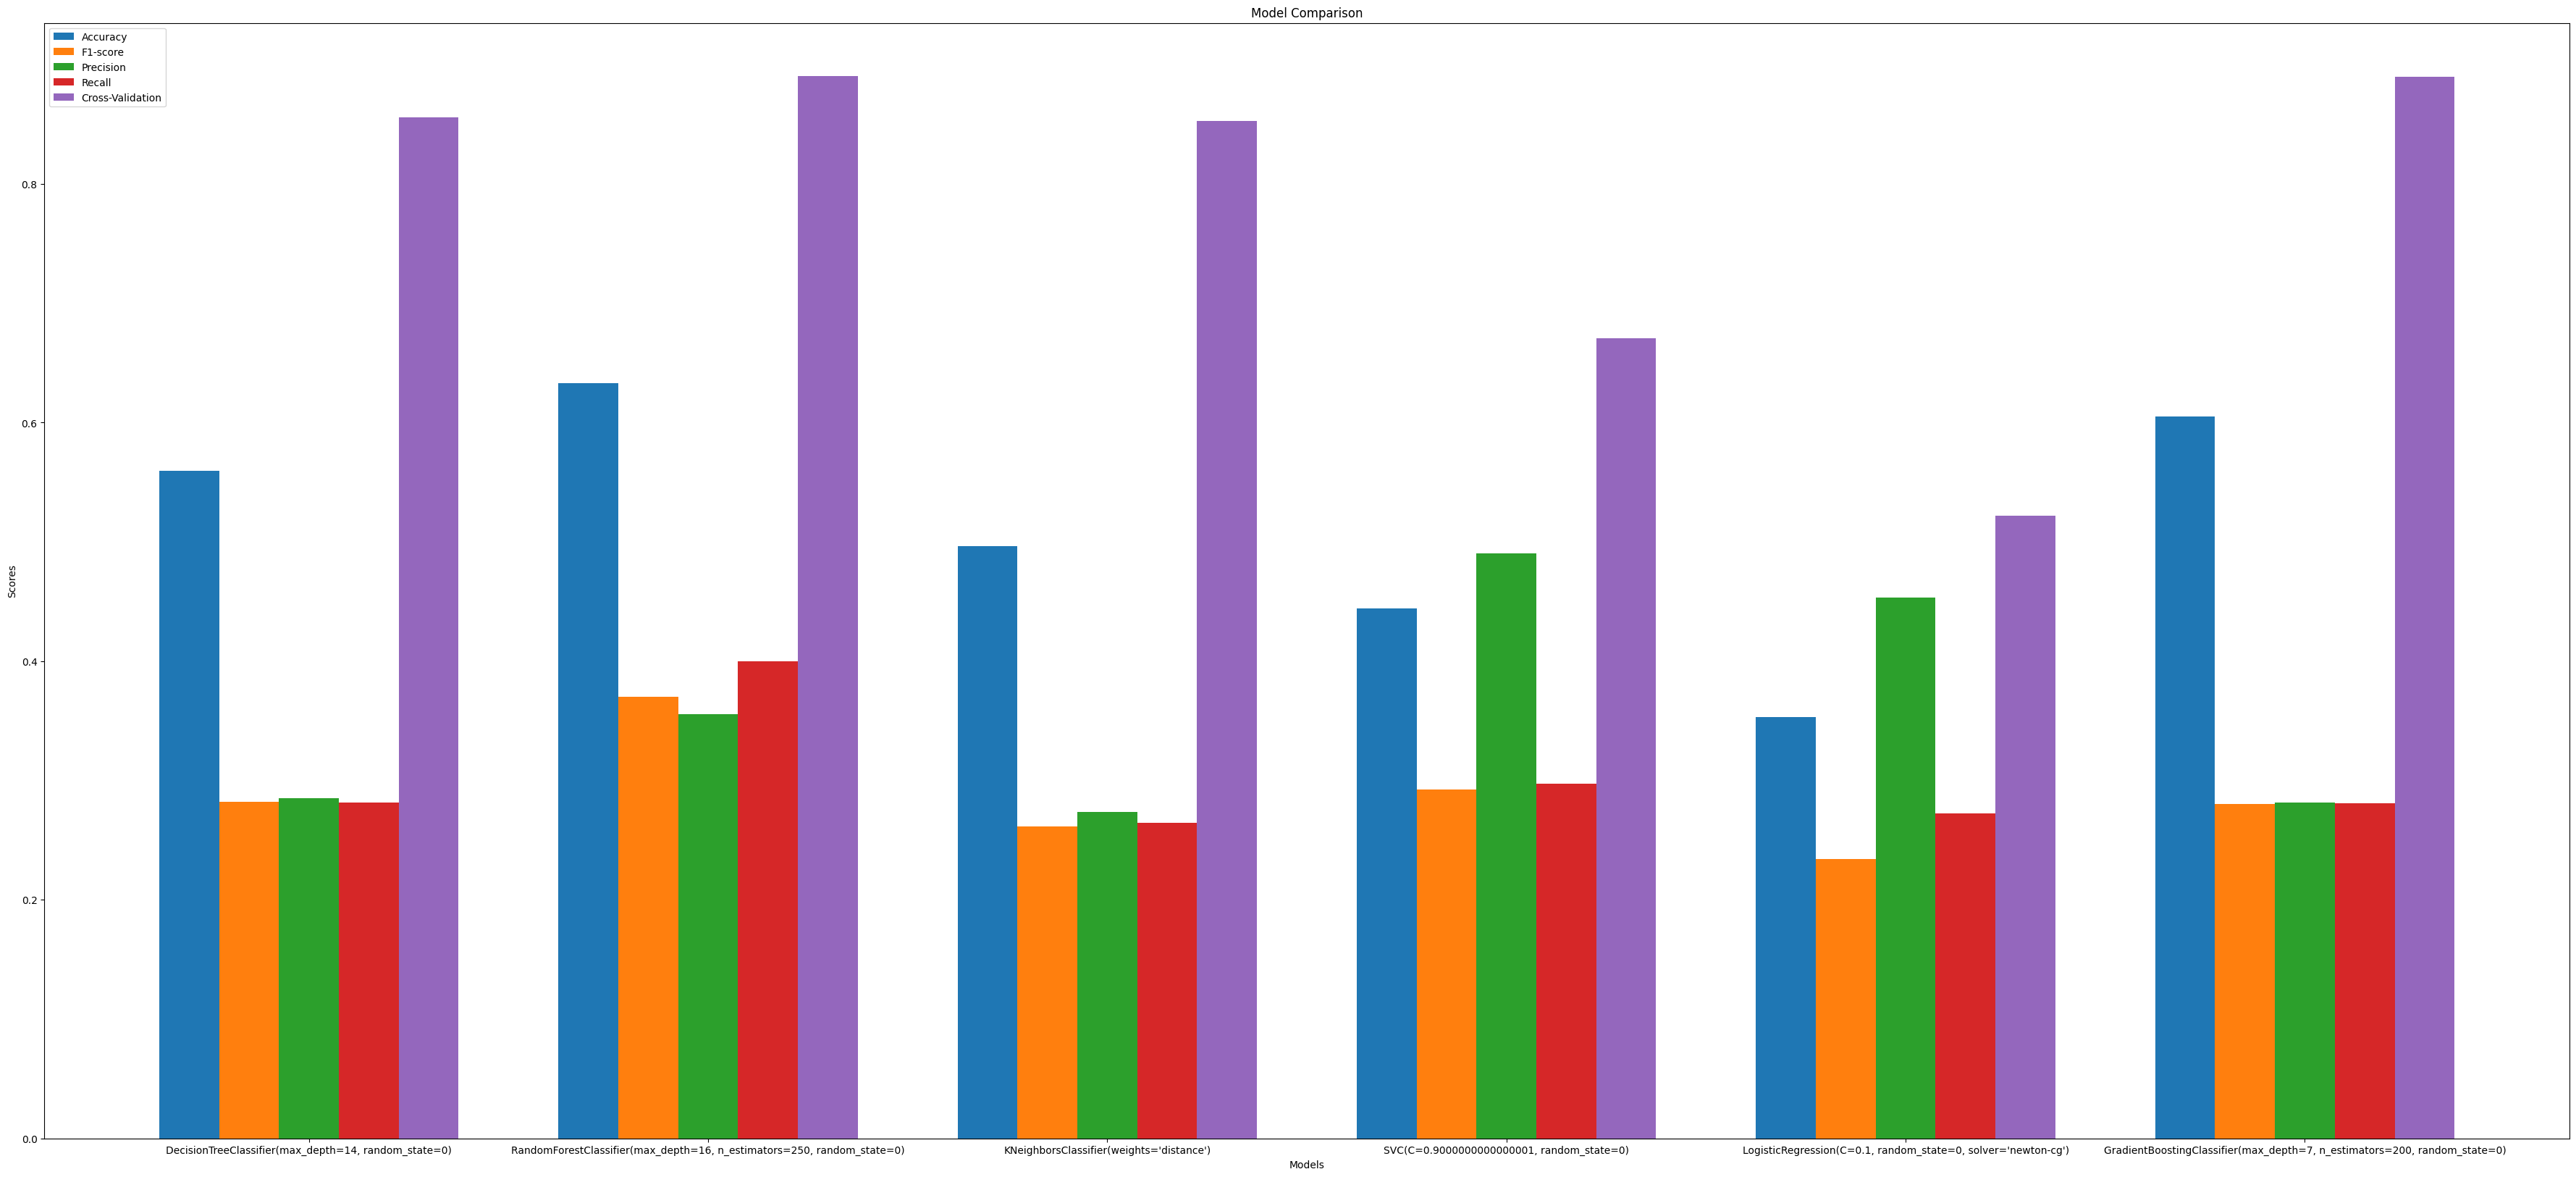


Results:
                                                     Accuracy   F1-score   
DecisionTreeClassifier(max_depth=14, random_sta...  55.944056  28.230943  \
RandomForestClassifier(max_depth=16, n_estimato...  63.286713  36.988802   
KNeighborsClassifier(weights='distance')            49.650350  26.137044   
SVC(C=0.9000000000000001, random_state=0)           44.405594  29.236255   
LogisticRegression(C=0.1, random_state=0, solve...  35.314685  23.403684   
GradientBoostingClassifier(max_depth=7, n_estim...  60.489510  27.996179   

                                                    Precision     Recall   
DecisionTreeClassifier(max_depth=14, random_sta...  28.538586  28.144591  \
RandomForestClassifier(max_depth=16, n_estimato...  35.543193  39.999409   
KNeighborsClassifier(weights='distance')            27.336386  26.429701   
SVC(C=0.9000000000000001, random_state=0)           49.003752  29.715358   
LogisticRegression(C=0.1, random_state=0, solve...  45.333428  27.260169   
G

In [143]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.ensemble import GradientBoostingClassifier

models = [
    DecisionTreeClassifier(random_state=0, max_depth=14),
    RandomForestClassifier(random_state=0, max_depth=16, n_estimators=250),
    KNeighborsClassifier(n_neighbors=5, weights='distance'),
    SVC(random_state=0, C=0.9000000000000001, kernel='rbf'),
    LogisticRegression(random_state=0, C=0.1, solver='newton-cg'),
    GradientBoostingClassifier(random_state=0, learning_rate=0.1, max_depth=7, n_estimators=200)
]
models_comparison = {}

for model in models:
    print(f"Model: {str(model)}\n")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracies = cross_val_score(estimator=model, X=X_train, y=y_train, cv=5)
    print(classification_report(y_test, y_pred))
    print("-" * 30, "\n")
    models_comparison[f"{str(model)}"] = [
        accuracy_score(y_pred, y_test),
        f1_score(y_pred, y_test, average="macro"),
        precision_score(y_pred, y_test, average="macro"),
        recall_score(y_pred, y_test, average="macro"),
        (accuracies.mean()),
        (accuracies.std())  # Add standard deviation
    ]
    
# Plotting comparative bar chart
labels = list(models_comparison.keys())
accuracy_scores = [val[0] for val in models_comparison.values()]
f1_scores = [val[1] for val in models_comparison.values()]
precision_scores = [val[2] for val in models_comparison.values()]
recall_scores = [val[3] for val in models_comparison.values()]
cross_val_scores = [val[4] for val in models_comparison.values()]

x = range(len(labels))
width = 0.15

plt.figure(figsize=(45, 20))

plt.bar(x, accuracy_scores, width, label='Accuracy')
plt.bar([val + width for val in x], f1_scores, width, label='F1-score')
plt.bar([val + 2 * width for val in x], precision_scores, width, label='Precision')
plt.bar([val + 3 * width for val in x], recall_scores, width, label='Recall')
plt.bar([val + 4 * width for val in x], cross_val_scores, width, label='Cross-Validation')

plt.xlabel('Models')
plt.ylabel('Scores')
plt.title('Model Comparison')
plt.xticks([val + 2 * width for val in x], labels)
plt.legend()

plt.show()

# Creating a DataFrame for results
results_df = pd.DataFrame(models_comparison.values(), index=models_comparison.keys(), columns=[
    'Accuracy', 'F1-score', 'Precision', 'Recall', 'Cross-Validation', 'Std Deviation'
])

# Convert decimal scores to percentage
results_df[['Accuracy', 'F1-score', 'Precision', 'Recall']] *= 100

print("\nResults:")
print(results_df)